# Assignment 1: House Price Prediction with Linear Models
### Machine Learning and Predictive Modelling (DSS5104)

---

#### Group 9 Members:
1. **Vivian Witjaksono** – A0326440M  
2. **Chaisathid Patanan** – A0327119E  
3. **Raissa Shafira Indra** – A0329591U

# Library Dependencies

In [1]:
# Environment Setup and Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import HuberRegressor, ElasticNet
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import Pipeline
from patsy import dmatrix
from IPython.display import display
import scipy.stats as stats
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Data Import and Preparation

In [2]:
# Load Dataset
data = pd.read_csv('house_dataset.csv')

In [3]:
# Display the Data
print(data.shape)
data.head()

(9200, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# Data Cleaning and Preprocessing

In [4]:
# Duplicate Detection
duplicate_count = data.duplicated().sum()
print(f"Number of duplicates found: {duplicate_count}")

# Duplicate Removal
# The dataset was assessed for exact duplicates
# 4,598 redundant rows were identified and removed  to prevent bias in the predictive model
data.drop_duplicates(inplace=True)
print(data.shape)

Number of duplicates found: 4598
(4602, 18)


In [5]:
# Zero Price Detection
print((data['price'] == 0).sum())

# Zero Price Handling
# 49 records with a price of $0 as invalid transaction were removed to keep the dataset realistic
data = data[data['price'] > 0].reset_index(drop=True)
print(data.shape)

49
(4553, 18)


In [6]:
# Zero Bedroom/Bathroom Detection
print(((data['bedrooms'] == 0) | (data['bathrooms'] == 0)).sum())

# Zero Bedroom/Bathroom Handling
# 2 records were removed as anomalies to focus the model on standard housing data
data = data[(data['bedrooms'] > 0) & (data['bathrooms'] > 0)].reset_index(drop=True)
print(data.shape)

2
(4551, 18)


In [7]:
# SQFT Consistency Check
print((data['sqft_living'] != (data['sqft_above'] + data['sqft_basement'])).sum())

# SQFT Handling
# Rows with inconsistent living area values were removed to avoid calculation errors
data = data[data['sqft_living'] == (data['sqft_above'] + data['sqft_basement'])].reset_index(drop=True)
print(data.shape)

2
(4549, 18)


In [8]:
# Renovation Year Refinement
print(((data['yr_renovated'] == 0) | (data['yr_renovated'] < data['yr_built'])).sum())

# Rows with 0 or renovation years earlier than 'yr_built' were adjusted to match 'yr_built' to maintain logical timeline
data['yr_renovated'] = np.where(
    (data['yr_renovated'] == 0) | (data['yr_renovated'] < data['yr_built']),
    data['yr_built'],
    data['yr_renovated']
)

# Verification Check: Compare Built vs Renovated year
print(data[['yr_built', 'yr_renovated']].head())

2899
   yr_built  yr_renovated
0      1955          2005
1      1921          1921
2      1966          1966
3      1963          1963
4      1976          1992


In [9]:
# Street Duplicate Analysis
street_counts = data['street'].value_counts()
repeated_streets = street_counts[street_counts > 1]
print(f"Number of street addresses appearing more than once: {len(repeated_streets)}")

# Repeated Sales Check
# Identifies properties with the same street and living area (SQFT) to capture actual repeated sales of the same unit
actual_property_dups = data.duplicated(subset=['street', 'sqft_living'], keep=False).sum()
print(f"Number of rows that are actual repeated sales (Same Street & Same SQFT): {actual_property_dups}")

Number of street addresses appearing more than once: 72
Number of rows that are actual repeated sales (Same Street & Same SQFT): 24


In [10]:
# Street Duplicate Cleansing
# 72 street addresses appeared multiple times, but only 24 rows were actual repeated sales (same street and living area).
# Retained only the most recent transaction for these cases

# Store the number of rows before cleaning
rows_before = data.shape[0]
# Sort by street, sqft, and date (latest date first)
data = data.sort_values(by=['street', 'sqft_living', 'date'], ascending=[True, True, False])

# Drop duplicates only for street + sqft_living
data = data.drop_duplicates(subset=['street', 'sqft_living'], keep='first').reset_index(drop=True)

# Store the number of rows after cleaning
rows_after = data.shape[0]

# Calculate the number of rows removed during the duplicate cleansing process
rows_removed = rows_before - rows_after

print(f"Rows removed after duplicate cleansing: {rows_removed}")
print(f"Data shape after cleansing: {data.shape}")

Rows removed after duplicate cleansing: 12
Data shape after cleansing: (4537, 18)


# Basic Derived Variables

In [11]:
# Basic Derived Variables: House Age & Renovation Recency

# Convert sale date to year
data['date'] = pd.to_datetime(data['date'])
data['year_sold'] = data['date'].dt.year

# Create age-related features
# 'house_age' = years since built
# 'years_since_renovation' = years since last renovation
data['house_age'] = data['year_sold'] - data['yr_built']
data['years_since_renovation'] = data['year_sold'] - data['yr_renovated']

# Verification Check: compare built/renovated years with calculated ages
print(data[['yr_built', 'yr_renovated', 'year_sold', 'house_age', 'years_since_renovation']].head())

   yr_built  yr_renovated  year_sold  house_age  years_since_renovation
0      2012          2012       2014          2                       2
1      2006          2006       2014          8                       8
2      1900          2005       2014        114                       9
3      2004          2004       2014         10                      10
4      1974          1974       2014         40                      40


In [12]:
# Basic Derived Variables: Zipcode Extraction

# The 'statezip' column contains both the state code (WA) and the numeric zipcode
# Since all properties are in Washington, the state info is redundant
# Extract the numeric zipcode to use as a categorical location feature
data['zipcode'] = data['statezip'].str.split(' ', expand=True)[1]

# Verification Check: Compare the statezip and new zipcode
print(data[['statezip', 'zipcode']].head())

   statezip zipcode
0  WA 98019   98019
1  WA 98119   98119
2  WA 98112   98112
3  WA 98112   98112
4  WA 98027   98027


In [13]:
# Column Cleanup

# Remove constant or redundant columns:
# - 'country' (only one value: USA)
# - 'statezip' and 'street' (redundant after zipcode extraction)
# - 'yr_built' and 'yr_renovated' (captured in derived age features)
# This prevents multicollinearity, ensuring a more stable and accurate Linear Regression model.
cols_to_drop = ['country', 'statezip', 'street', 'yr_built', 'yr_renovated']

# Dropping the columns
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Verification Check
print("Dataset Columns:")
print(data.columns.tolist())
print(f"\nDataset Shape: {data.shape}")
data.head()

Dataset Columns:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'city', 'year_sold', 'house_age', 'years_since_renovation', 'zipcode']

Dataset Shape: (4537, 17)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,city,year_sold,house_age,years_since_renovation,zipcode
0,2014-06-25,309620.0,3.0,2.50,1860,3730,2.0,0,0,3,1860,0,Duvall,2014,2,2,98019
1,2014-07-02,625000.0,3.0,3.00,1820,1641,3.0,0,0,3,1540,280,Seattle,2014,8,8,98119
2,2014-07-01,600000.0,2.0,1.00,910,2002,1.5,0,0,3,910,0,Seattle,2014,114,9,98112
3,2014-05-06,460000.0,2.0,2.25,1230,929,2.0,0,0,3,1020,210,Seattle,2014,10,10,98112
4,2014-07-02,575000.0,3.0,1.75,2680,8625,1.0,0,0,5,1590,1090,Issaquah,2014,40,40,98027


In [14]:
# Final Integrity Check

# Verify categorical/ordinal features contain expected values
print("Unique values in 'waterfront':", data['waterfront'].unique())
print("Unique values in 'view':", data['view'].unique())
print("Unique values in 'condition':", data['condition'].unique())
print("Unique values in 'floors':", data['floors'].unique())

# Check for zero values in key SQFT columns
print("\nZero values in sqft_living:", (data['sqft_living'] == 0).sum())
print("Zero values in sqft_above:", (data['sqft_above'] == 0).sum())

# Check for missing values (NaN) after cleaning
print("\nTotal Missing Values (NaN):")
print(data.isnull().sum().sum())

Unique values in 'waterfront': [0 1]
Unique values in 'view': [0 1 2 3 4]
Unique values in 'condition': [3 5 4 2 1]
Unique values in 'floors': [2.  3.  1.5 1.  2.5 3.5]

Zero values in sqft_living: 0
Zero values in sqft_above: 0

Total Missing Values (NaN):
0


# Target Variable Transformation & Visualization

In [15]:
# Target Variable Transformation: Log Price

# Apply Log Transformation to Price
data['log_price'] = np.log1p(data['price'])

# Drop original 'date' column (non-numeric)
data.drop(columns=['date'], inplace=True, errors='ignore')

# Verification Check
print("Data Head with Log Price:")
print(data[['price', 'log_price']].head())
print(f"\nData Shape for Modelling: {data.shape}")

Data Head with Log Price:
      price  log_price
0  309620.0  12.643104
1  625000.0  13.345509
2  600000.0  13.304687
3  460000.0  13.038984
4  575000.0  13.262127

Data Shape for Modelling: (4537, 17)


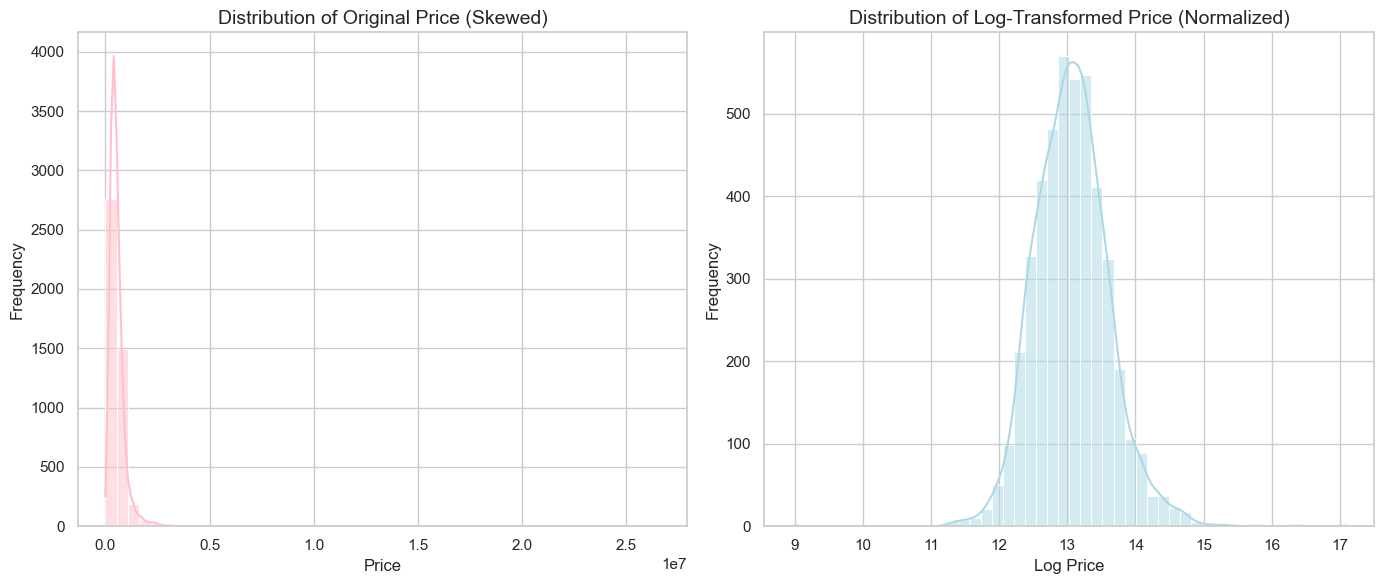

In [16]:
# Target Variable Visualization: Price Distribution

# Compare original vs log-transformed price distributions
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot 1: Original Price Distribution
plt.subplot(1, 2, 1)
sns.histplot(data['price'], kde=True, color='pink', bins=50)
plt.title('Distribution of Original Price (Skewed)', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')

# Plot 2: Log-Transformed Price Distribution
plt.subplot(1, 2, 2)
sns.histplot(data['log_price'], kde=True, color='lightblue', bins=50)
plt.title('Distribution of Log-Transformed Price (Normalized)', fontsize=14)
plt.xlabel('Log Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### Price Distribution and Log Transformation

The original price distribution is highly right-skewed due to a few extremely expensive outliers.  
After applying a **log transformation**, the distribution becomes more symmetric and closer to a **normal (bell-shaped) curve**.  

This normalization reduces skewness, making the **target variable** more suitable for regression modelling.

# Exploratory Data Analysis

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/1715289868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='bedrooms', ax=axes[0], palette='viridis')
/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/1715289868.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='floors', ax=axes[2], palette='pastel')


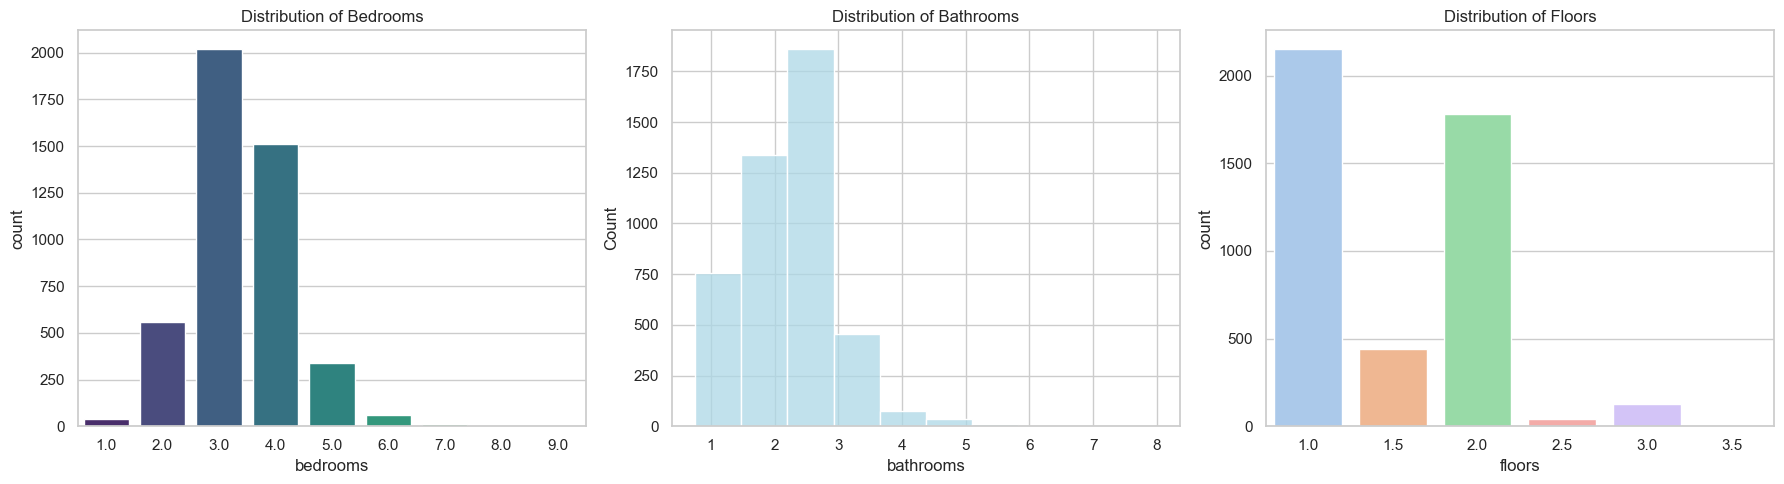

In [17]:
# EDA: Univariate Analysis of Housing Attributes

# Visualize distributions of Bedrooms, Bathrooms, and Floors
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Bedrooms
sns.countplot(data=data, x='bedrooms', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Bedrooms')

# Plot Bathrooms
sns.histplot(data=data, x='bathrooms', bins=10, ax=axes[1], color='lightblue')
axes[1].set_title('Distribution of Bathrooms')

# Plot Floors
sns.countplot(data=data, x='floors', ax=axes[2], palette='pastel')
axes[2].set_title('Distribution of Floors')

plt.tight_layout()
plt.show()

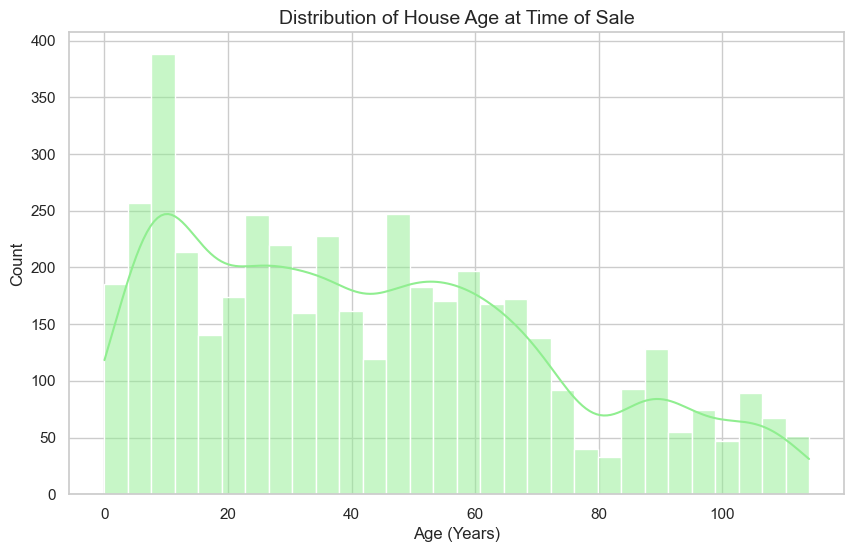

In [18]:
# EDA: Univariate Analysis - House Age

# Visualize the distribution of the 'house_age' feature
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='house_age', kde=True, color='lightgreen', bins=30)
plt.title('Distribution of House Age at Time of Sale', fontsize=14)
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.show()

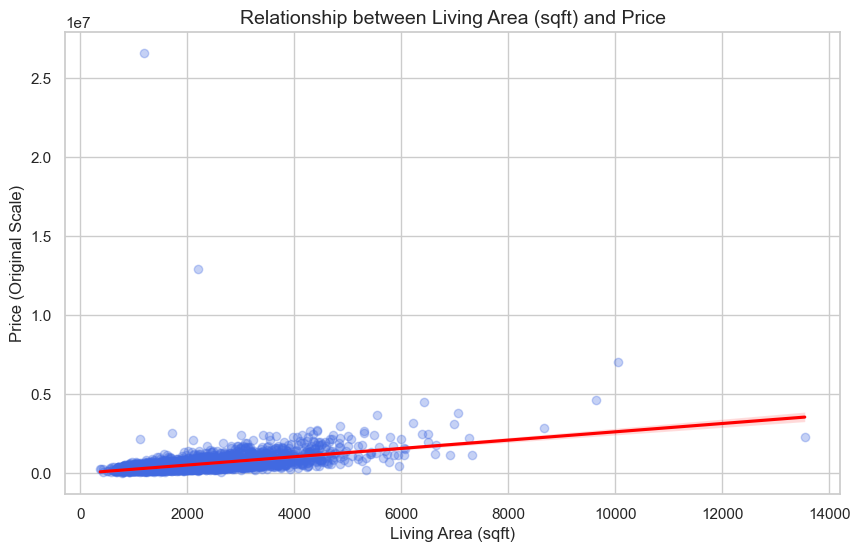

In [19]:
# EDA: Bivariate Analysis - Price vs Living Area

# Scatter plot with regression line to show relationship
plt.figure(figsize=(10, 6))

sns.regplot(data=data, x='sqft_living', y='price',
            scatter_kws={'alpha':0.3, 'color':'royalblue'},
            line_kws={'color':'red'})

plt.title('Relationship between Living Area (sqft) and Price', fontsize=14)
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price (Original Scale)')
plt.show()

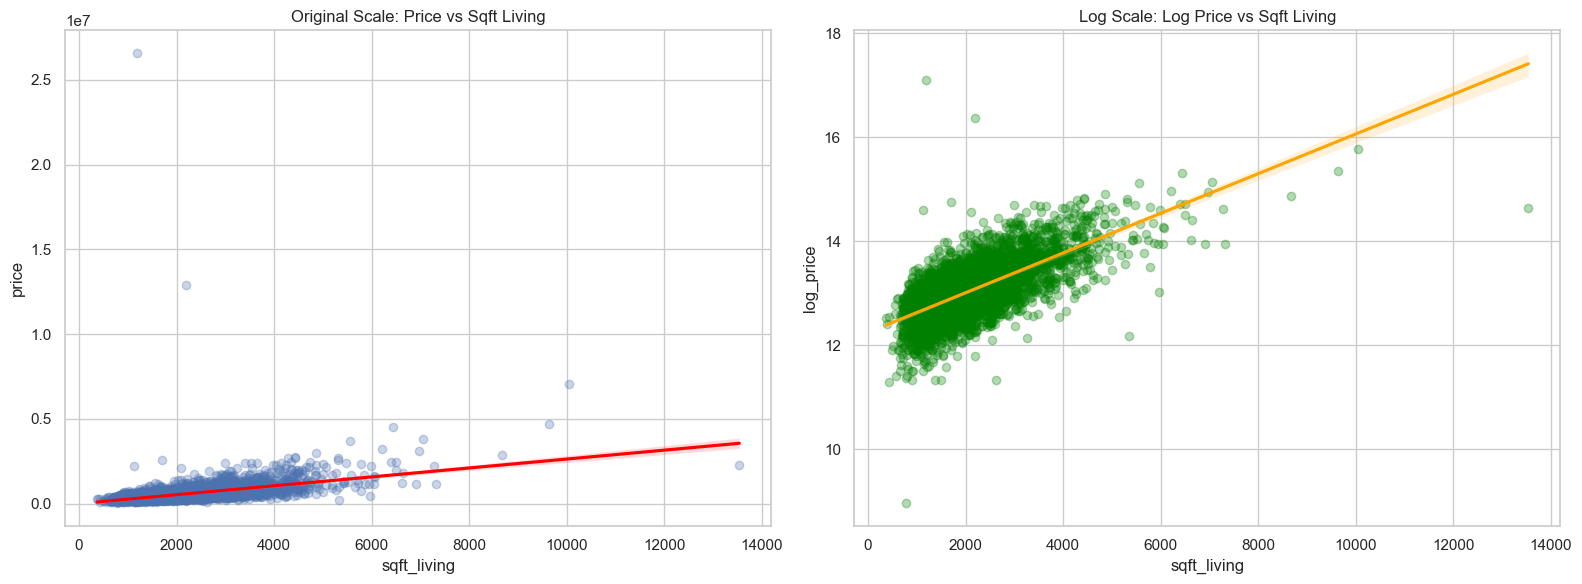

In [20]:
# EDA: Bivariate Analysis - Price vs Living Area (Original vs Log Scale)

# Compare variance and linearity before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original Scale
sns.regplot(data=data, x='sqft_living', y='price', ax=axes[0],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Original Scale: Price vs Sqft Living')

# Plot 2: Log Scale
sns.regplot(data=data, x='sqft_living', y='log_price', ax=axes[1],
            scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'orange'})
axes[1].set_title('Log Scale: Log Price vs Sqft Living')

plt.tight_layout()
plt.show()

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/3016351536.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='bedrooms', y='log_price', palette='Pastel1')


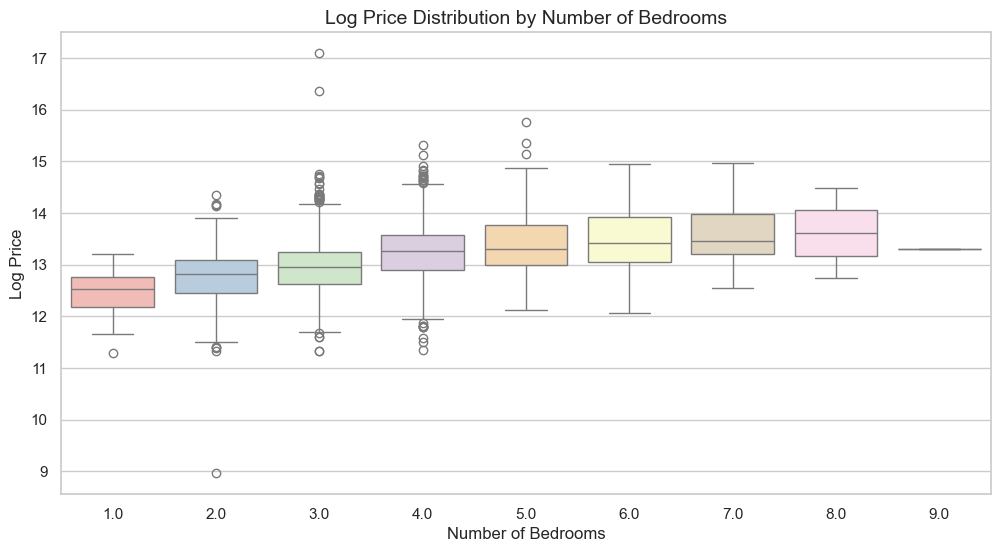

In [21]:
# EDA: Bivariate Analysis - Bedrooms vs Log Price

# Boxplot to show price distribution across bedroom counts
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, x='bedrooms', y='log_price', palette='Pastel1')

plt.title('Log Price Distribution by Number of Bedrooms', fontsize=14)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Log Price')
plt.show()

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/3076980465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='condition', y='log_price', ax=axes[0], palette='Pastel1')
/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/3076980465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='view', y='log_price', ax=axes[1], palette='Pastel2')


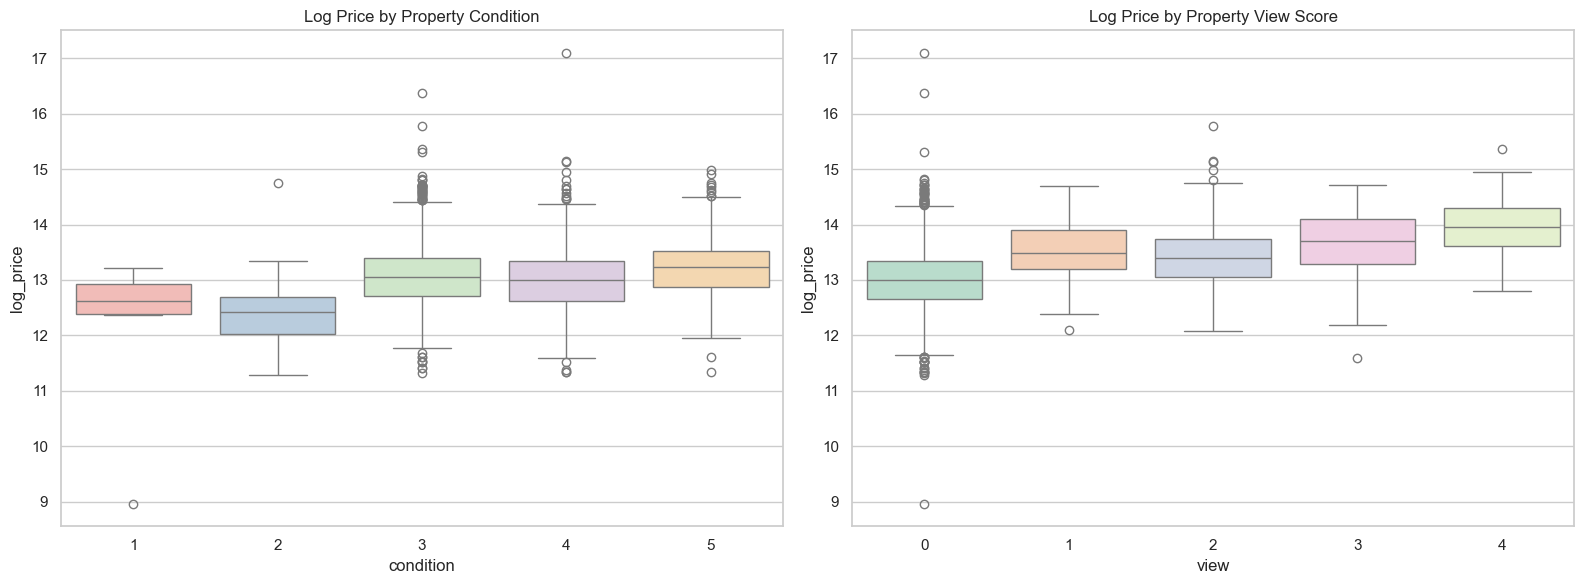

In [22]:
# EDA: Bivariate Analysis - Condition & View vs Log Price

# Boxplots to show price distribution across quality tiers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Condition vs Log Price
sns.boxplot(data=data, x='condition', y='log_price', ax=axes[0], palette='Pastel1')
axes[0].set_title('Log Price by Property Condition')

# Plot 2: View vs Log Price
sns.boxplot(data=data, x='view', y='log_price', ax=axes[1], palette='Pastel2')
axes[1].set_title('Log Price by Property View Score')

plt.tight_layout()
plt.show()

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/979589859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='Reds_r')


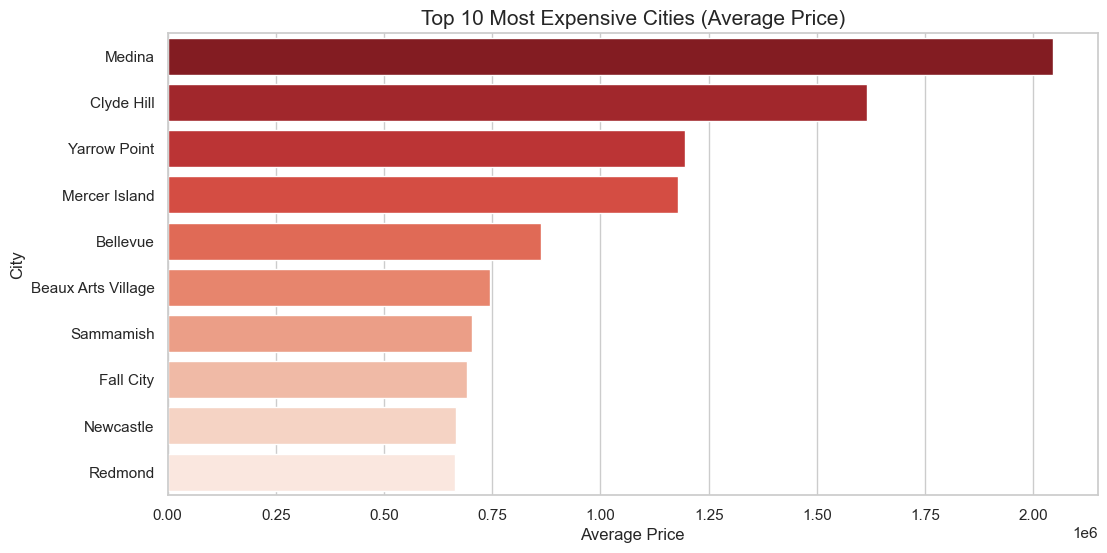

In [23]:
# EDA: Bivariate Analysis - Average Price by City (Top 10)

# Barplot to show top 10 most expensive cities
top_10_cities = data.groupby('city')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='Reds_r')
plt.title('Top 10 Most Expensive Cities (Average Price)', fontsize=15)
plt.xlabel('Average Price')
plt.ylabel('City')
plt.show()

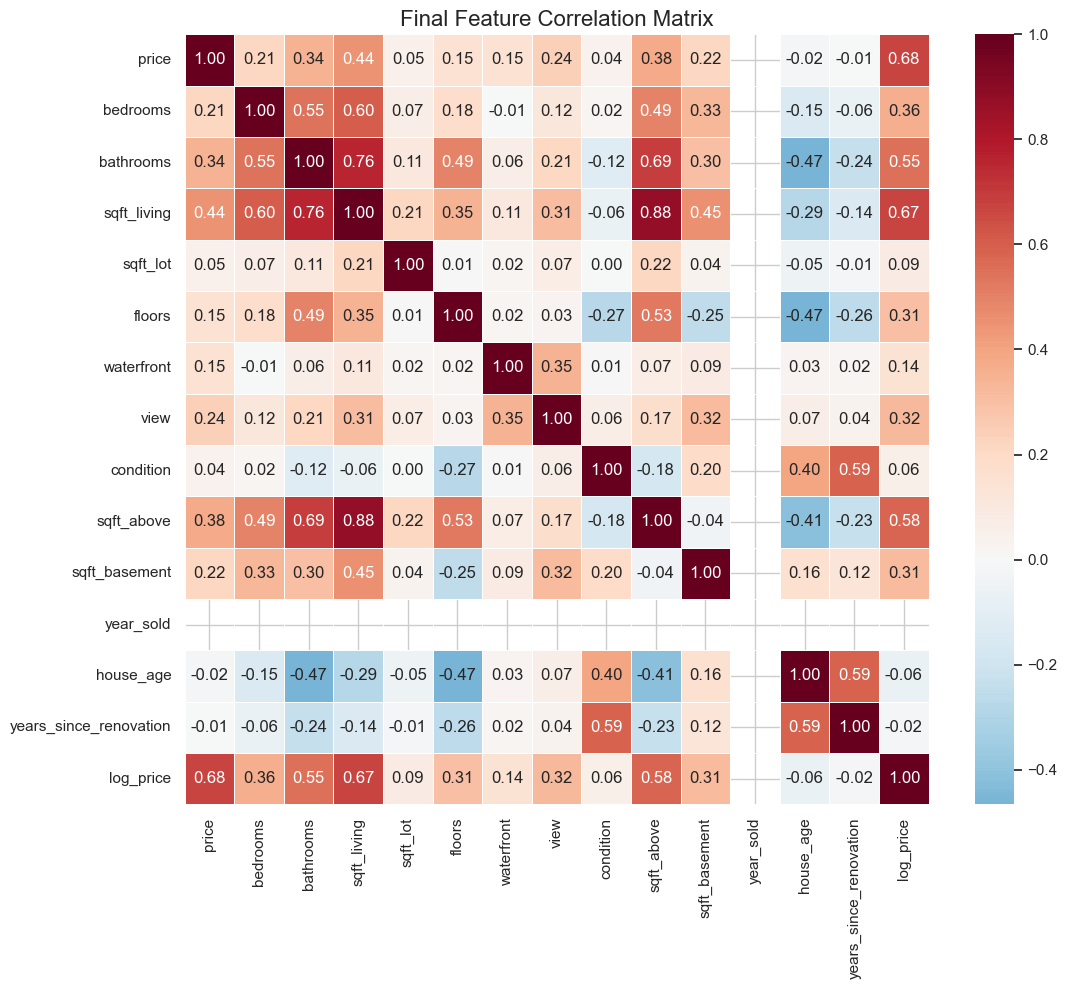

In [24]:
# EDA: Correlation Analysis - Numerical Features vs Log Price

# Heatmap to summarize feature relationships and detect multicollinearity
plt.figure(figsize=(12, 10))
corr_matrix = data.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Final Feature Correlation Matrix', fontsize=16)
plt.show()

##### Feature Correlation Analysis

While the correlation heatmap provides a comprehensive overview of feature relationships, some variables may show **undefined or missing correlations**.  

To investigate this further, we examined the temporal feature **`year_sold`**.  
By checking its **variance**, we ensure that only **informative predictors** are retained, avoiding redundant features that contribute no **discriminatory power** to the model.

In [25]:
# EDA: Temporal Consistency Check - Year Sold

# Verify variance and correlation of 'year_sold' with target
# Checking the distribution of sales years
print("Value Counts for 'year_sold':")
print(data['year_sold'].value_counts())

# Checking correlation with the target price
print("\nCorrelation between 'year_sold' and 'price':")
print(data[['year_sold', 'price']].corr())

Value Counts for 'year_sold':
year_sold
2014    4537
Name: count, dtype: int64

Correlation between 'year_sold' and 'price':
           year_sold  price
year_sold        NaN    NaN
price            NaN    1.0


##### Finalizing Feature Selection

After confirming that **`year_sold`** provides no variance and accounts for the missing correlations in the heatmap, we proceed to **finalize our feature selection**.  

Removing **redundant or constant variables** ensures the dataset is **streamlined** and contains only **meaningful predictors** for regression modelling.

In [26]:
# EDA: Final Feature Selection and Removal

# Drop constant and redundant features before modelling
# Drop the constant 'year_sold' and the original 'price' column
# Keep 'log_price' as our actual target for the model
cols_to_drop = ['year_sold', 'price', 'date']
data_ready = data.drop(columns=cols_to_drop, errors='ignore')

print("Remaining features for the final heatmap:")
print(data_ready.columns.tolist())

Remaining features for the final heatmap:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'city', 'house_age', 'years_since_renovation', 'zipcode', 'log_price']


##### Validating Feature Selection with Correlation Heatmap

After removing **redundant and constant variables**, we regenerate the **correlation heatmap** to validate the remaining feature set.  

This final matrix ensures that only **meaningful predictors** are retained and highlights the **strongest relationships** with the target variable **`log_price`**.

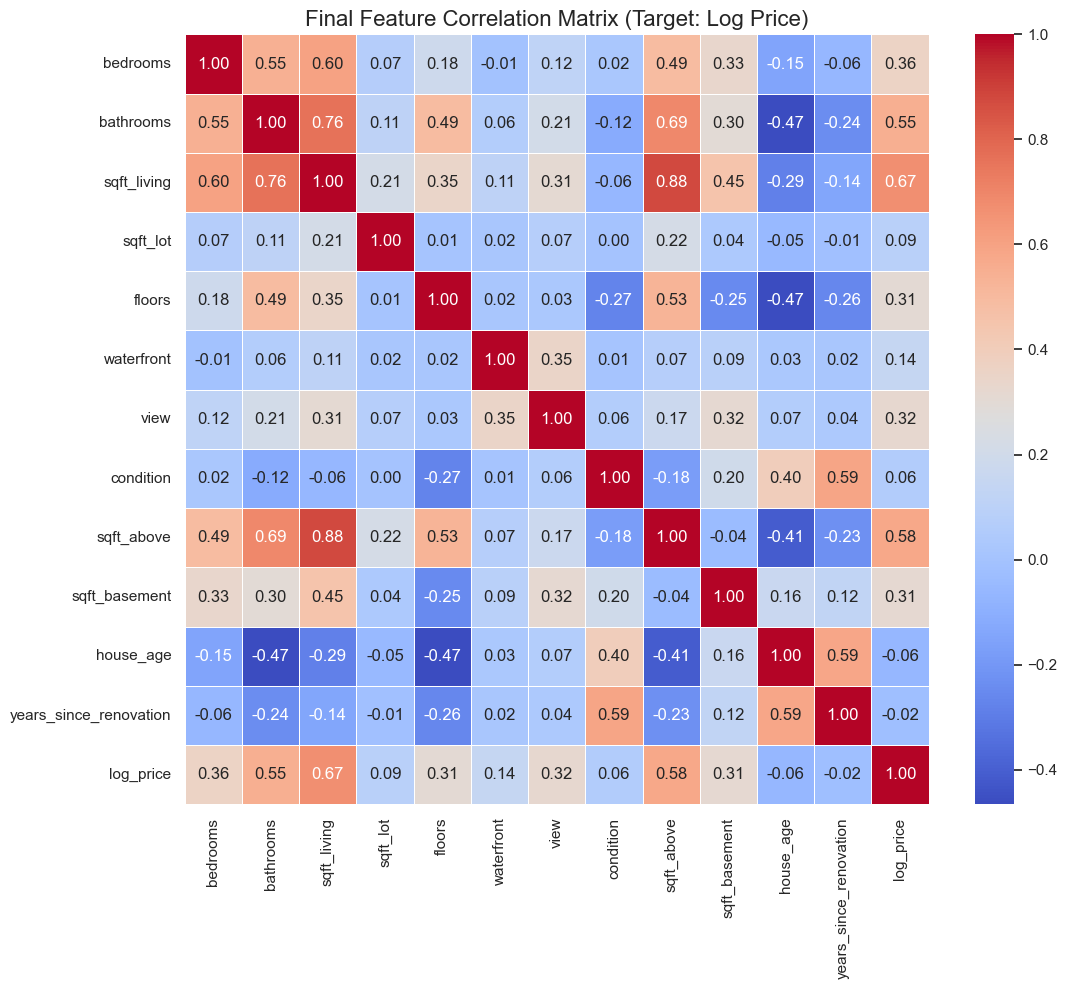

In [27]:
# EDA: Final Correlation Analysis - Updated Feature Set

# Heatmap of numerical features after feature removal
plt.figure(figsize=(12, 10))

# Calculating correlation for the updated numeric dataset
final_corr = data_ready.select_dtypes(include=[np.number]).corr()

# Plot heatmap
sns.heatmap(final_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Final Feature Correlation Matrix (Target: Log Price)', fontsize=16)
plt.show()

# Preparation for Machine Learning Processing

In [28]:
# Preparation for Machine Learning - Label Encoding
# Transform categorical features (city, zipcode) into numeric format
# Create final dataframe (data_final) for modelling

# Initialize the encoder
le = LabelEncoder()

# Create a final copy of the dataframe for modelling
data_final = data_ready.copy()

# Save original categorical series before encoding
# These will be used for KFold target encoding in Feature Engineering step
city_series   = data_ready['city'].astype(str).copy()
zip_series    = data_ready['zipcode'].astype(str).copy()
log_price_ref = data_ready['log_price'].copy()

# Transform text categories into numerical integers
data_final['city'] = le.fit_transform(data_final['city'])
data_final['zipcode'] = le.fit_transform(data_final['zipcode'])

# Display the first few rows to verify everything is now numeric
print("Final Encoded Dataset (Top 5 Rows):")
print(data_final.head())


Final Encoded Dataset (Top 5 Rows):
   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0       2.50         1860      3730     2.0           0     0   
1       3.0       3.00         1820      1641     3.0           0     0   
2       2.0       1.00          910      2002     1.5           0     0   
3       2.0       2.25         1230       929     2.0           0     0   
4       3.0       1.75         2680      8625     1.0           0     0   

   condition  sqft_above  sqft_basement  city  house_age  \
0          3        1860              0    11          2   
1          3        1540            280    35          8   
2          3         910              0    35        114   
3          3        1020            210    35         10   
4          5        1590           1090    16         40   

   years_since_renovation  zipcode  log_price  
0                       2       11  12.643104  
1                       8       58  13.345509  
2       

In [29]:
# Preparation for Machine Learning - Define Features and Target
# Separate predictors (X) from target variable (y = log_price)
# Used for baseline model only

X = data_final.drop(columns=['log_price'])
y = data_final['log_price']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (4537, 14)
Target (y) shape: (4537,)


In [30]:
# Preparation for Machine Learning - Train/Test Split

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set (X_train): {X_train.shape}")
print(f"Testing set (X_test): {X_test.shape}")

Training set (X_train): (3629, 14)
Testing set (X_test): (908, 14)


# Model Development and Baseline Performance

In [31]:
# Model Development - Baseline Linear Regression (OLS)

# Train baseline model, predict on test set, and transform predictions back to original scale
# Initialize and Train the Baseline Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Make Predictions (Log Scale)
log_predictions = baseline_model.predict(X_test)

# Transform back to Original Price Scale
# expm1 is used because used log1p earlier
y_pred_original = np.expm1(log_predictions)
y_test_original = np.expm1(y_test)

In [32]:
# Model Evaluation - Baseline Performance (MAPE & R²)

# Assess baseline regression model using MAPE & R²

# Calculate Baseline MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
baseline_mape = calculate_mape(y_test_original, y_pred_original)

# Calculate R-squared for the baseline (using log_price)
baseline_r2 = r2_score(y_test, log_predictions)

print(f"Baseline Performance")
print(f"R-Squared Score: {baseline_r2:.4f}")
print(f"MAPE: {baseline_mape:.2f}%")

Baseline Performance
R-Squared Score: 0.4796
MAPE: 30.59%


In [33]:
# Cross-Validation - Baseline OLS

# Define K-Fold (5-fold CV)
kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer = make_scorer(mape_original_scale, greater_is_better=False)

cv_mape_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=kf,
    scoring=mape_scorer
)

# Convert negative MAPE back to positive
cv_mape_scores_baseline = -cv_mape_scores

print("Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_baseline.mean():.2f}%")

Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.5527
Average CV MAPE (original scale): 30.68%


##### Baseline Model Performance

The baseline model yields **R² = 0.48** and **MAPE = 30.59%**, showing moderate fit but relatively high error.

##### Cross-validation (5-fold) confirms model stability:
- **Average CV R² (log scale) = 0.55**, slightly higher than test R², indicating that the model generalizes reasonably well across different subsets of the training data.  
- **Average CV MAPE (original scale) = 30.68%**, nearly identical to the test MAPE, showing that prediction errors are consistent and not highly dependent on a particular train-test split.

##### Summary

This suggests that while the baseline linear model captures some of the variance, there is still **room for improvement**. The model is **stable**, but error remains relatively high, motivating the next steps: **feature engineering and regularization** to enhance predictive performance.

# Feature Engineering & Regularization

In [34]:
# Feature Engineering - Polynomial, Interaction, and Domain Features

# Add non-linear term (sqft_living²), interaction (sqft_living × condition), and luxury indicator

# Creating new engineered features
data_engineered = data_final.copy()

# Polynomial Term
data_engineered['sqft_living_squared'] = data_engineered['sqft_living'] ** 2

# Interaction Term
data_engineered['living_x_condition'] = data_engineered['sqft_living'] * data_engineered['condition']

# Luxury Indicator
# If view is high and condition is high, it's a luxury property
data_engineered['is_luxury'] = ((data_engineered['view'] > 2) & (data_engineered['condition'] > 3)).astype(int)

# Preview the new features
print(data_engineered[['sqft_living', 'sqft_living_squared', 'living_x_condition', 'is_luxury']].head())

   sqft_living  sqft_living_squared  living_x_condition  is_luxury
0         1860              3459600                5580          0
1         1820              3312400                5460          0
2          910               828100                2730          0
3         1230              1512900                3690          0
4         2680              7182400               13400          0


In [35]:
# Model Development - Re-Run with Engineered Features

# Train regression model on new feature set and compare performance to baseline

X_eng = data_engineered.drop(columns=['log_price'])
y_eng = data_engineered['log_price']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

# Train the model
model_eng = LinearRegression()
model_eng.fit(X_train_e, y_train_e)

# Evaluate the model
y_pred_e = model_eng.predict(X_test_e)
mape_e = calculate_mape(np.expm1(y_test_e), np.expm1(y_pred_e))
r2_e = r2_score(y_test_e, y_pred_e)

print(f"Engineered Model Performance_1")
print(f"New R-Squared Score: {r2_e:.4f} (Old: {baseline_r2:.4f})")
print(f"New MAPE: {mape_e:.2f}% (Old: {baseline_mape:.2f}%)")

Engineered Model Performance_1
New R-Squared Score: 0.5141 (Old: 0.4796)
New MAPE: 28.26% (Old: 30.59%)


In [36]:
# Cross-Validation-Engineered Model Performance_1

# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores = cross_val_score(
    LinearRegression(),
    X_eng,
    y_eng,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_scorer_func(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer = make_scorer(mape_scorer_func, greater_is_better=False)

cv_mape_scores = cross_val_score(
    LinearRegression(),
    X_eng,
    y_eng,
    cv=kf,
    scoring=mape_scorer
)

# Convert negative MAPE back to positive
cv_mape_scores_e = -cv_mape_scores

print("Engineered Model Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_e.mean():.2f}%")

Engineered Model Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.5520
Average CV MAPE (original scale): 29.96%


##### Engineered Features Performance

Engineered features improved the model to **R² = 0.51** and **MAPE = 28.26%**, showing clear gains over the baseline.

##### Engineered Model Cross-Validation Performance (5-Fold)
- **Average CV R² (log scale) = 0.55**  
- **Average CV MAPE (original scale) = 29.96%**  

##### Summary

This shows that the model improvements are consistent across different folds, confirming that the **engineered features** enhance **predictive stability** and **generalization** compared to the baseline.

Building on this improvement, we now extend feature engineering with **binning** and **neighborhood signals** to capture **categorical size effects** and **localized market patterns**.

In [37]:
# Feature Engineering - Age Binning & Location Signals

# Add categorical age groups and target-based city price signal
# Age Binning (Categorizing by Era)
# 0-5 years: New, 5-20: Modern, 20-50: Established, 50+: Vintage
def age_category(age):
    if age <= 5: return 0
    elif age <= 20: return 1
    elif age <= 50: return 2
    else: return 3

data_engineered['age_category'] = data_engineered['house_age'].apply(age_category)

# Location Signal (KFold Target Encoding)
# Replace city categories with their mean log_price
# so the model understands location premium numerically.
# KFold prevents data leakage
# each row's mean is computed from other folds only, never from itself.

def kfold_target_encode(series, target, n_splits=5, random_state=42):

    # Initialize output array with NaN
    encoded = np.full(len(series), np.nan)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for tr_idx, va_idx in kf.split(series):

        # Compute mean log_price per city using training folds only
        means = target.iloc[tr_idx].groupby(series.iloc[tr_idx]).mean()

        # Assign mean to validation fold rows
        encoded[va_idx] = series.iloc[va_idx].map(means).values

    # Fill any unseen categories with global mean
    encoded = np.where(np.isnan(encoded), target.mean(), encoded)

    return encoded

# City-level location premium (added here)
data_engineered['city_price_signal'] = kfold_target_encode(city_series, log_price_ref)

# Verify the new features
print(data_engineered[['house_age', 'age_category', 'city', 'city_price_signal']].head())

# Drop original city column after verification
data_engineered.drop(columns=['city'], inplace=True, errors='ignore')

   house_age  age_category  city  city_price_signal
0          2             0    11          12.877506
1          8             1    35          13.136001
2        114             3    35          13.138191
3         10             1    35          13.138191
4         40             2    16          13.274873


In [38]:
# Model Development - Re-Run with Enhanced Features

# Train regression model with location signal and evaluate performance

X_enh = data_engineered.drop(columns=['log_price'])
y_enh = data_engineered['log_price']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_enh, y_enh, test_size=0.2, random_state=42)

# Train the model
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_h, y_train_h)

# Evaluate the model
y_pred_h = model_enhanced.predict(X_test_h)
mape_h = calculate_mape(np.expm1(y_test_h), np.expm1(y_pred_h))
r2_h = r2_score(y_test_h, y_pred_h)

print(f"Enhanced Model Performance")
print(f"R-Squared Score: {r2_h:.4f}")
print(f"MAPE: {mape_h:.2f}%")
print(f"Improvement from previous stage: {mape_e - mape_h:.2f}%")


Enhanced Model Performance
R-Squared Score: 0.6160
MAPE: 21.79%
Improvement from previous stage: 6.47%


In [39]:
# Cross-Validation - Enhanced Model Performance

kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores_h = cross_val_score(
    LinearRegression(),
    X_enh,
    y_enh,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_scorer_func_h(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_h = make_scorer(mape_scorer_func_h, greater_is_better=False)

cv_mape_scores_h = cross_val_score(
    LinearRegression(),
    X_enh,
    y_enh,
    cv=kf,
    scoring=mape_scorer_h
)

cv_mape_scores_h = -cv_mape_scores_h

print("Enhanced Model Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores_h.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_h.mean():.2f}%")

Enhanced Model Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7008
Average CV MAPE (original scale): 21.74%


##### Enhanced Model Performance with Location Signals and Age Binning

With **location signals** and **age binning**, the model improved further to **R² = 0.62** and **MAPE = 21.79%**, showing a stronger fit and significantly lower error.

##### Enhanced Model Cross-Validation Performance (5-Fold)
- **Average CV R² (log scale) = 0.70**  
- **Average CV MAPE (original scale) = 21.74%**  

This indicates that the improvements from location signals and age binning are consistent across different folds. The model not only fits the test data better (**R² = 0.70, MAPE = 21.74%**), but also demonstrates stronger **generalization** and **stability** compared to the previous stage.

##### Next Steps

To push performance further, we introduce **domain-specific ratios** and **indicator variables** (e.g., **lot utilization**, **average room size**, **renovation flag**, **basement flag**) that capture practical property characteristics beyond raw features.

In [40]:
# Feature Engineering - Domain Ratios & Indicators

# Add lot utilization, avg room size, basement flag, and renovation flag

# Living Area Ratio (How much of the lot is used for living space)
data_engineered['lot_utilization'] = data_engineered['sqft_living'] / data_engineered['sqft_lot']

# Average Room Size (Proxy for luxury/spaciousness)
# Adding 0.1 to avoid division by zero
data_engineered['avg_room_size'] = data_engineered['sqft_living'] / (data_engineered['bedrooms'] + data_engineered['bathrooms'] + 0.1)

# Binary Indicator: Has Basement?
data_engineered['has_basement'] = (data_engineered['sqft_basement'] > 0).astype(int)

# Binary Indicator: Ever Renovated?
# If yr_renovated was 0, it means it was never renovated (based on our earlier analysis)
data_engineered['is_renovated'] = (data_engineered['years_since_renovation'] < data_engineered['house_age']).astype(int)

# Preview the new domain features
print(data_engineered[['lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated']].head())

   lot_utilization  avg_room_size  has_basement  is_renovated
0         0.498660     332.142857             0             0
1         1.109080     298.360656             1             0
2         0.454545     293.548387             0             1
3         1.324004     282.758621             1             0
4         0.310725     552.577320             1             0


In [41]:
# Model Development - Re-Run with additional new features

# Train regression model with new features

X_final = data_engineered.drop(columns=['log_price'])
y_final = data_engineered['log_price']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Train the model
model_final = LinearRegression()
model_final.fit(X_train_f, y_train_f)

# Evaluate the model
y_pred_f = model_final.predict(X_test_f)
mape_f = calculate_mape(np.expm1(y_test_f), np.expm1(y_pred_f))
r2_f = r2_score(y_test_f, y_pred_f)

print(f"Engineered Model Performance_2")
print(f"R-Squared Score: {r2_f:.4f}")
print(f"MAPE: {mape_f:.2f}%")
print(f"Improvement from previous stage: {mape_h - mape_f:.2f}%")

Engineered Model Performance_2
R-Squared Score: 0.6252
MAPE: 21.58%
Improvement from previous stage: 0.21%


In [42]:
# Cross-Validation - Engineered Model Performance 2

kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores_f = cross_val_score(
    LinearRegression(),
    X_final,
    y_final,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_scorer_func_f(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_f = make_scorer(mape_scorer_func_f, greater_is_better=False)

cv_mape_scores_f = cross_val_score(
    LinearRegression(),
    X_final,
    y_final,
    cv=kf,
    scoring=mape_scorer_f
)

cv_mape_scores_f = -cv_mape_scores_f

print("Engineered Model Cross-Validation Performance_2 (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores_f.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_f.mean():.2f}%")

Engineered Model Cross-Validation Performance_2 (5-Fold)
Average CV R² (log scale): 0.7052
Average CV MAPE (original scale): 21.66%


##### Final Engineered Model Performance

With all new engineered features combined, the model reached **R² = 0.63** and **MAPE = 21.58%**, a slight improvement over the previous stage (**0.21% error reduction**).

##### Engineered Model Cross-Validation Performance_2 (5-Fold)
- **Average CV R² (log scale) = 0.71**  
- **Average CV MAPE (original scale) = 21.66%**  

This shows that the improvements from combining all new engineered features are consistent across different folds. The model also demonstrates **stability** and **generalization**, confirming that the additional features meaningfully enhance **predictive performance**.

##### Introducing Neighborhood Similarity Features (KNN)

To capture even finer **local market dynamics**, we now introduce **Neighborhood Similarity Features (KNN)**.  
By leveraging **geographic proximity** (city and zipcode), the model gains a **spatial signal** through the **average price of nearby properties**, enhancing its ability to reflect **localized price trends**.

In [43]:
# Feature Engineering - Neighborhood Similarity (KNN)

# Add zipcode-level signal first, then use both city + zipcode as KNN input
# to capture neighborhood-level price patterns more precisely than city alone

# Zipcode-level location premium (added here alongside KNN)
data_engineered['zipcode_price_signal'] = kfold_target_encode(zip_series, log_price_ref)

# Drop original zipcode column
data_engineered.drop(columns=['zipcode'], inplace=True, errors='ignore')

# KNN Neighborhood Price Proxy
# For each house, find 10 nearest neighbors by location (city + zipcode signals)
# and average their log_price — captures hyper-local price patterns
# KFold prevents leakage: each row's proxy is predicted from other folds only
knn_cols = ['city_price_signal', 'zipcode_price_signal']

# Identify train/test indices (must match downstream split)
_idx = data_engineered.index.to_numpy()
_train_idx, _test_idx = train_test_split(_idx, test_size=0.2, random_state=42)

knn_proxy = np.zeros(len(data_engineered))

# Generate proxy for TRAIN rows via 5-Fold CV (no leakage)
kf_knn = KFold(n_splits=5, shuffle=True, random_state=42)
train_loc = data_engineered.loc[_train_idx]

for tr_rel, va_rel in kf_knn.split(train_loc):
    tr_abs = train_loc.iloc[tr_rel].index
    va_abs = train_loc.iloc[va_rel].index

    sc  = RobustScaler()
    knn = KNeighborsRegressor(n_neighbors=10)
    knn.fit(
        sc.fit_transform(data_engineered.loc[tr_abs, knn_cols]),
        data_engineered.loc[tr_abs, 'log_price']
    )
    knn_proxy[data_engineered.index.get_indexer(va_abs)] = knn.predict(
        sc.transform(data_engineered.loc[va_abs, knn_cols])
    )

# Generate proxy for TEST rows using KNN fitted on ALL train rows
sc_final  = RobustScaler()
knn_final = KNeighborsRegressor(n_neighbors=10)
knn_final.fit(
    sc_final.fit_transform(data_engineered.loc[_train_idx, knn_cols]),
    data_engineered.loc[_train_idx, 'log_price']
)
knn_proxy[data_engineered.index.get_indexer(_test_idx)] = knn_final.predict(
    sc_final.transform(data_engineered.loc[_test_idx, knn_cols])
)

# Attach the leakage-free proxy
data_engineered['neighbor_price_proxy'] = knn_proxy

print("neighbor_price_proxy created (leakage-free).")
print(f"  Train rows filled : {len(_train_idx)}")
print(f"  Test  rows filled : {len(_test_idx)}")

neighbor_price_proxy created (leakage-free).
  Train rows filled : 3629
  Test  rows filled : 908


In [44]:
# Model Development - Re-Run with KNN features

# Train regression model

X_knn = data_engineered.drop(columns=['log_price'])
y_knn = data_engineered['log_price']

X_train_kn, X_test_kn, y_train_kn, y_test_kn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# Train the standard Linear Regression model with KNN feature
model_knn = LinearRegression()
model_knn.fit(X_train_kn, y_train_kn)

# Evaluate the model
y_pred_kn = model_knn.predict(X_test_kn)
mape_kn = calculate_mape(np.expm1(y_test_kn), np.expm1(y_pred_kn))
r2_kn = r2_score(y_test_kn, y_pred_kn)

print(f"KNN-Enhanced Model Performance")
print(f"R-Squared Score: {r2_kn:.4f}")
print(f"MAPE: {mape_kn:.2f}%")
print(f"Improvement from previous stage: {mape_f - mape_kn:.2f}%")

KNN-Enhanced Model Performance
R-Squared Score: 0.6929
MAPE: 18.52%
Improvement from previous stage: 3.06%


In [45]:
# Cross-Validation - KNN-Enhanced Model Performance

kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores_kn = cross_val_score(
    LinearRegression(),
    X_knn,
    y_knn,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_scorer_func_kn(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_kn = make_scorer(mape_scorer_func_kn, greater_is_better=False)

cv_mape_scores_kn = cross_val_score(
    LinearRegression(),
    X_knn,
    y_knn,
    cv=kf,
    scoring=mape_scorer_kn
)

cv_mape_scores_kn = -cv_mape_scores_kn

print("KNN-Enhanced Model Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores_kn.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_kn.mean():.2f}%")

KNN-Enhanced Model Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7706
Average CV MAPE (original scale): 18.64%


##### Model Performance with Neighborhood Similarity (KNN)

By adding the **neighborhood similarity proxy**, the model improved to **R² = 0.69** and **MAPE = 18.52%**, delivering a notable **3.06% error reduction** compared to the previous stage.

##### KNN-Enhanced Model Cross-Validation Performance (5-Fold)
- **Average CV R² (log scale) = 0.77**  
- **Average CV MAPE (original scale) = 18.64%**  

The addition of the neighborhood similarity proxy shows consistent improvements across folds, enhancing both **fit** and **generalization**.

##### Next Steps: K-Means Clustering & Log Transformation

We now advance to **K-Means Clustering** and **log transformation**.  
- **Clustering** uncovers latent neighborhood types.  
- **Log-transforming skewed features** (e.g., `sqft_lot`) helps **linearize relationships**, further strengthening the model’s **predictive power**.

In [46]:
# Feature Engineering - Clustering & Log Transformations

# Add neighborhood clusters, log-transformed lot size, and historic age flag

# Clustering based on Location and Size
# Use city_price_signal and zipcode_price_signal (meaningful values)
# instead of LabelEncoder integers which have no spatial meaning
# Tell the model to find 8 types of "Neighborhood Clusters"

# Note: KMeans is fit on full dataset — acceptable here because KMeans is
# unsupervised and does not use price (target), so no target leakage occurs.
coords = data_engineered[['city_price_signal', 'zipcode_price_signal', 'sqft_living']]
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
data_engineered['cluster_label'] = kmeans.fit_predict(coords)

# Handling Skewed Features with Log
# Lot size often has extreme outliers
data_engineered['log_sqft_lot'] = np.log1p(data_engineered['sqft_lot'])

# Binning House Age into more specific eras
data_engineered['is_historic'] = (data_engineered['house_age'] > 75).astype(int)

# Adding Quality-Size Interactions
# this captures the premium of high-quality space
data_engineered['quality_area_interaction'] = data_engineered['condition'] * data_engineered['sqft_living']

print("Advanced features added: 'cluster_label', 'log_sqft_lot', and 'is_historic', and 'quality_area_interaction'.")

Advanced features added: 'cluster_label', 'log_sqft_lot', and 'is_historic', and 'quality_area_interaction'.


In [47]:
# Model Development - Re-Run with additional advanced features

# Train model

X_ultimate = data_engineered.drop(columns=['log_price'])
y_ultimate = data_engineered['log_price']

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_ultimate, y_ultimate, test_size=0.2, random_state=42)

model_ultimate = LinearRegression()
model_ultimate.fit(X_train_u, y_train_u)

# Evaluate the model
y_pred_u = model_ultimate.predict(X_test_u)
mape_u = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_u))
r2_u = r2_score(y_test_u, y_pred_u)

print(f"Engineered Model Performance_3")
print(f"R-Squared Score: {r2_u:.4f}")
print(f"MAPE: {mape_u:.2f}%")
print(f"Improvement from previous stage: {mape_kn - mape_u:.2f}%")

Engineered Model Performance_3
R-Squared Score: 0.6942
MAPE: 18.54%
Improvement from previous stage: -0.02%


In [48]:
# Cross-Validation - Engineered Model Performance_3

kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Cross-Validation R² (Log Scale)
cv_r2_scores_u = cross_val_score(
    LinearRegression(),
    X_ultimate,
    y_ultimate,
    cv=kf,
    scoring='r2'
)

# MAPE Scorer (Original Scale)
def mape_scorer_func_u(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_u = make_scorer(mape_scorer_func_u, greater_is_better=False)

cv_mape_scores_u = cross_val_score(
    LinearRegression(),
    X_ultimate,
    y_ultimate,
    cv=kf,
    scoring=mape_scorer_u
)

cv_mape_scores_u = -cv_mape_scores_u

print("Engineered Model Cross-Validation Performance_3 (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_scores_u.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_scores_u.mean():.2f}%")

Engineered Model Cross-Validation Performance_3 (5-Fold)
Average CV R² (log scale): 0.7723
Average CV MAPE (original scale): 18.55%


##### Engineered Model Cross-Validation Performance_3 (5-Fold)
- **Average CV R² (log scale) = 0.77**  
- **Average CV MAPE (original scale) = 18.55%**  

##### Observations from Clustering and Log Transformation

In our previous experiment, we introduced **clustering** and **log-transformed lot sizes** to test for further improvements.  
While these additions marginally increased **R²**, the **MAPE** slightly rose from **18.52%** to **18.54%**, indicating that **OLS has reached its complexity ceiling**.  
Additional raw features alone are unlikely to provide further gains.

##### Next Step: Regularized Linear Models

Rather than discarding any engineered features, **all features are retained**.  
The next step transitions to **Regularized Linear Models** (**Ridge**, **Lasso**, **ElasticNet**).  
Regularization will **penalize redundant or noisy coefficients automatically**, making this the appropriate response to the observed ceiling, rather than manual feature removal.

In [49]:
# Model Development - Regularized Linear Models
# Apply Ridge (L2) and Lasso (L1) regression for stability and generalization

# RobustScaler instead of StandardScaler — more robust to house price outliers
# Uses median and IQR instead of mean and std, less affected by extreme values
scaler = RobustScaler()
X_train_final = scaler.fit_transform(X_train_u)
X_test_final = scaler.transform(X_test_u)

# Ridge Regression (Handles multicollinearity)
ridge_final = Ridge(alpha=1.0)
ridge_final.fit(X_train_final, y_train_u)
y_pred_ridge = ridge_final.predict(X_test_final)
mape_ridge = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_ridge))
r2_ridge = r2_score(y_test_u, y_pred_ridge)

# Lasso Regression (Performs Feature Selection)
lasso_final = Lasso(alpha=0.001)
lasso_final.fit(X_train_final, y_train_u)
y_pred_lasso = lasso_final.predict(X_test_final)
mape_lasso = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_lasso))
r2_lasso = r2_score(y_test_u, y_pred_lasso)

print(f"Regularization Results")
print(f"Ridge MAPE: {mape_ridge:.2f}% | R2: {r2_ridge:.4f}")
print(f"Lasso MAPE: {mape_lasso:.2f}% | R2: {r2_lasso:.4f}")
print(f"Previous OLS MAPE: {mape_u:.2f}%")

Regularization Results
Ridge MAPE: 18.52% | R2: 0.6947
Lasso MAPE: 18.40% | R2: 0.6978
Previous OLS MAPE: 18.54%


In [50]:
# Cross-Validation - Ridge & Lasso

kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Pipeline: scaler fits only on train fold within each CV iteration — prevents leakage
ridge_pipeline = Pipeline([('scaler', RobustScaler()), ('ridge', Ridge(alpha=1.0))])
lasso_pipeline = Pipeline([('scaler', RobustScaler()), ('lasso', Lasso(alpha=0.001))])

# Ridge CV
cv_r2_ridge = cross_val_score(
    ridge_pipeline,       
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring='r2'
)

def mape_scorer_ridge(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_ridge_fn = make_scorer(mape_scorer_ridge, greater_is_better=False)

cv_mape_ridge = -cross_val_score(
    ridge_pipeline,       
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring=mape_scorer_ridge_fn
)

print("Ridge Regression Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_ridge.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_ridge.mean():.2f}%")

# Lasso CV
cv_r2_lasso = cross_val_score(
    lasso_pipeline,       
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring='r2'
)

def mape_scorer_lasso(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_lasso_fn = make_scorer(mape_scorer_lasso, greater_is_better=False)

cv_mape_lasso = -cross_val_score(
    lasso_pipeline,      
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring=mape_scorer_lasso_fn
)

print("Lasso Regression Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_lasso.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_lasso.mean():.2f}%")

Ridge Regression Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7724
Average CV MAPE (original scale): 18.55%
Lasso Regression Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7718
Average CV MAPE (original scale): 18.56%


##### Regularized Linear Models Performance

- **Ridge Regression:** MAPE = 18.52%, R² = 0.69  
- **Lasso Regression:** MAPE = 18.40%, R² = 0.70  

Both regularized models provide **stability** and marginal gains over the previous model (MAPE = 18.54%).

##### Observations

The **Ridge** and **Lasso** models show very consistent results across folds, indicating **stable generalization**.

##### Next Step: Robust Regression & ElasticNet

To further enhance robustness, we now explore **Robust Regression (Huber)** and **ElasticNet**, which:  
- Balance **sensitivity to outliers**  
- Combine **L1/L2 penalties**  

This step aims to **minimize prediction errors** in the presence of **skewed markets** and ensure a **resilient final model**.

In [51]:
# Model Development - Robust & Hybrid Regression

# Apply Huber (robust to outliers) and ElasticNet (L1+L2 balance)

# Huber Regressor (Robust to Outliers)
huber = HuberRegressor(max_iter=2000)
huber.fit(X_train_final, y_train_u)
y_pred_huber = huber.predict(X_test_final)
mape_huber = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_huber))
r2_huber = r2_score(y_test_u, y_pred_huber)

# ElasticNet (Balance of L1 and L2)
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic.fit(X_train_final, y_train_u)
y_pred_elastic = elastic.predict(X_test_final)
mape_elastic = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_elastic))
r2_elastic = r2_score(y_test_u, y_pred_elastic)

print(f"Huber Regressor : MAPE = {mape_huber:.2f}% | R2 = {r2_huber:.4f}")
print(f"ElasticNet      : MAPE = {mape_elastic:.2f}% | R2 = {r2_elastic:.4f}")
print(f"Lasso MAPE: {mape_lasso:.2f}%")


Huber Regressor : MAPE = 18.53% | R2 = 0.6951
ElasticNet      : MAPE = 18.43% | R2 = 0.6970
Lasso MAPE: 18.40%


In [52]:
# Cross-Validation - Huber & ElasticNet

kf = KFold(n_splits=5, shuffle=True, random_state=88)
r2_scores = []
mape_scores_huber = []

# Huber CV 
for train_idx, test_idx in kf.split(X_ultimate):
    X_tr, X_te = X_ultimate.iloc[train_idx], X_ultimate.iloc[test_idx]
    y_tr, y_te = y_ultimate.iloc[train_idx], y_ultimate.iloc[test_idx]

    sc_huber = RobustScaler()
    X_tr_sc = sc_huber.fit_transform(X_tr)
    X_te_sc = sc_huber.transform(X_te)

    huber = HuberRegressor(max_iter=2000)
    huber.fit(X_tr_sc, y_tr)
    y_pred = huber.predict(X_te_sc)

    r2_scores.append(r2_score(y_te, y_pred))
    mape_scores_huber.append(calculate_mape(np.expm1(y_te), np.expm1(y_pred)))

print("Huber CV")
print(f"Average CV R²: {np.mean(r2_scores):.4f}")
print(f"Average CV MAPE: {np.mean(mape_scores_huber):.2f}%")

# ElasticNet CV
# Pipeline: scaler fits only on train fold within each CV iteration — prevents leakage
elastic_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('elastic', ElasticNet(alpha=0.001, l1_ratio=0.5))
])

def mape_scorer_elastic(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_elastic_fn = make_scorer(mape_scorer_elastic, greater_is_better=False)

cv_r2_elastic = cross_val_score(
    elastic_pipeline,     
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring='r2'
)

cv_mape_elastic = -cross_val_score(
    elastic_pipeline,     
    X_ultimate,           
    y_ultimate,
    cv=kf,
    scoring=mape_scorer_elastic_fn
)

print("ElasticNet Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_elastic.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_elastic.mean():.2f}%")

Huber CV
Average CV R²: 0.7715
Average CV MAPE: 18.66%
ElasticNet Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7725
Average CV MAPE (original scale): 18.53%


##### ElasticNet vs Huber Regressor Performance

- **ElasticNet:** MAPE = 18.43%, R² = 0.70  
- **Huber Regressor:** MAPE = 18.53%, R² = 0.70  

ElasticNet slightly outperforms Huber, benefiting from **hybrid L1/L2 regularization**, while the Huber model remains highly competitive due to its **resistance to outliers**.

##### Next Step: Linear Ensemble (Average Blending)

To leverage the **complementary strengths** of these algorithms, we implement a **Linear Ensemble (Average Blending)** by combining:  
- **Lasso:** excels at **feature selection** and **regularization**  
- **Huber Regressor:** provides **robust protection against outliers**  

##### Purpose of Ensemble

This ensemble approach aims to **minimize variance** and **improve overall predictive accuracy**, surpassing the performance of any single model alone.

In [53]:
# Model Development - Linear Ensemble (Average Blending)

# Average predictions from Lasso (feature selection) and Huber (outlier robustness)

y_final_ensemble_log = (y_pred_lasso + y_pred_huber) / 2

# Evaluate the model
ensemble_mape = calculate_mape(np.expm1(y_test_u), np.expm1(y_final_ensemble_log))
ensemble_r2 = r2_score(y_test_u, y_final_ensemble_log)

print(f"LINEAR ENSEMBLE PERFORMANCE")
print(f"Ensemble R-Squared: {ensemble_r2:.4f}")
print(f"Ensemble MAPE: {ensemble_mape:.2f}%")

LINEAR ENSEMBLE PERFORMANCE
Ensemble R-Squared: 0.6971
Ensemble MAPE: 18.44%


In [54]:
# Cross Validation - Linear Ensemble

kf = KFold(n_splits=5, shuffle=True, random_state=88)
r2_scores = []
mape_scores_ensemble = []

for train_idx, test_idx in kf.split(X_ultimate):
    X_tr, X_te = X_ultimate.iloc[train_idx], X_ultimate.iloc[test_idx]
    y_tr, y_te = y_ultimate.iloc[train_idx], y_ultimate.iloc[test_idx]

    # Create new scaler per fold to prevent data leakage
    sc_cv = RobustScaler()
    X_tr_sc = sc_cv.fit_transform(X_tr)
    X_te_sc = sc_cv.transform(X_te)

    # Train base models — consistent with test set ensemble (Lasso + Huber)
    lasso_cv = Lasso(alpha=0.001)
    lasso_cv.fit(X_tr_sc, y_tr)

    huber_cv = HuberRegressor(max_iter=2000)
    huber_cv.fit(X_tr_sc, y_tr)

    # Ensemble: average predictions from Lasso and Huber (50/50)
    y_pred_ensemble = (lasso_cv.predict(X_te_sc) + huber_cv.predict(X_te_sc)) / 2

    # Evaluate fold
    r2_scores.append(r2_score(y_te, y_pred_ensemble))
    mape_scores_ensemble.append(calculate_mape(np.expm1(y_te), np.expm1(y_pred_ensemble)))

print("Linear Ensemble Cross-Validation Performance (5-Fold)")
print(f"Average CV R²: {np.mean(r2_scores):.4f}")
print(f"Average CV MAPE: {np.mean(mape_scores_ensemble):.2f}%")

Linear Ensemble Cross-Validation Performance (5-Fold)
Average CV R²: 0.7726
Average CV MAPE: 18.56%


##### Ensemble Model Performance

The **Ensemble model** achieved **R² = 0.70** and **MAPE = 18.44%**, slightly higher than the **ElasticNet** model (MAPE = 18.43%).

##### Next Step: Natural Cubic Splines

To further refine **non-linear relationships**, we explore **Natural Cubic Splines**:  
- Introducing spline transformations on **`sqft_living`** allows the model to capture **subtle bends** in the data.  
- **Lasso** ensures that only the **most relevant spline knots** are retained, potentially unlocking **additional predictive gains**.

In [55]:
# Model Development - Natural Cubic Splines
# Add spline features for sqft_living and train Lasso for non-linear effects

# Split BEFORE fitting spline knots — prevents test data from influencing knot positions
X_pre = data_engineered.drop(columns=['log_price'])
y_pre = data_engineered['log_price']
X_pre_train, X_pre_test, y_train_s, y_test_s = train_test_split(X_pre, y_pre, test_size=0.2, random_state=42)

# Fit spline basis on TRAIN data only — knot positions learned from training set only
spline_train = dmatrix("cr(train_data, df=4) - 1",
    {"train_data": X_pre_train['sqft_living']},
    return_type='dataframe')
spline_train.columns = [f'sqft_spline_{i}' for i in range(spline_train.shape[1])]

# Transform TEST set using the same knot structure learned from train
spline_test = dmatrix("cr(test_data, df=4) - 1",
    {"test_data": X_pre_test['sqft_living']},
    return_type='dataframe')
spline_test.columns = [f'sqft_spline_{i}' for i in range(spline_test.shape[1])]

# Combine spline features with original features for hold-out evaluation
X_train_s = pd.concat([X_pre_train.reset_index(drop=True), spline_train.reset_index(drop=True)], axis=1)
X_test_s  = pd.concat([X_pre_test.reset_index(drop=True),  spline_test.reset_index(drop=True)],  axis=1)

# Build full X_s for Cross-Validation (Cell 77)
# CV leakage is handled separately by Pipeline in the next cell
spline_all = dmatrix("cr(train_data, df=4) - 1",
    {"train_data": data_engineered['sqft_living']},
    return_type='dataframe')
spline_all.columns = [f'sqft_spline_{i}' for i in range(spline_all.shape[1])]
data_final_spline = pd.concat([data_engineered, spline_all], axis=1)
X_s = data_final_spline.drop(columns=['log_price'])
y_s = data_final_spline['log_price']

# Scaling and training Lasso
scaler_s = RobustScaler()
X_train_sc = scaler_s.fit_transform(X_train_s)
X_test_sc  = scaler_s.transform(X_test_s)

lasso_spline = Lasso(alpha=0.0001)
lasso_spline.fit(X_train_sc, y_train_s)

# Evaluate the model
y_pred_s = lasso_spline.predict(X_test_sc)
r2_s   = r2_score(y_test_s, y_pred_s)
mape_s = calculate_mape(np.expm1(y_test_s), np.expm1(y_pred_s))

print(f"Lasso Spline Results")
print(f"Lasso with Splines MAPE: {mape_s:.2f}%")
print(f"Lasso with Splines R2:   {r2_s:.4f}")

Lasso Spline Results
Lasso with Splines MAPE: 18.99%
Lasso with Splines R2:   0.6843


In [56]:
# Cross-Validation - Spline

# Define 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=88)

# Pipeline: scaler and Lasso are applied within each fold automatically
# This prevents leakage — scaler fits only on the train fold, never the validation fold
spline_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('lasso', Lasso(alpha=0.0001))
])

# CV for R² (log scale)
cv_r2_spline = cross_val_score(
    spline_pipeline,
    X_s,          # Pass raw X_s — Pipeline handles scaling internally per fold
    y_s,
    cv=kf,
    scoring='r2'
)

# CV for MAPE (original scale)
def mape_scorer_spline(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_scorer_spline_fn = make_scorer(mape_scorer_spline, greater_is_better=False)

cv_mape_spline = cross_val_score(
    spline_pipeline,
    X_s,          # Pass raw X_s — Pipeline handles scaling internally per fold
    y_s,
    cv=kf,
    scoring=mape_scorer_spline_fn
)

cv_mape_spline = -cv_mape_spline  # convert back to positive MAPE

print("Lasso + Splines Cross-Validation Performance (5-Fold)")
print(f"Average CV R² (log scale): {cv_r2_spline.mean():.4f}")
print(f"Average CV MAPE (original scale): {cv_mape_spline.mean():.2f}%")

Lasso + Splines Cross-Validation Performance (5-Fold)
Average CV R² (log scale): 0.7727
Average CV MAPE (original scale): 18.51%


##### Final Model Selection

After several experiments, the **Spline basis model** produced a slightly higher **MAPE = 18.99%** compared to the **ElasticNet model (MAPE = 18.43%)**.  

Hence, the **ElasticNet model** is chosen as the **final model** for this study.

##### Final Model Justification: ElasticNet

Although **Lasso** achieved the best individual test-set performance (**MAPE = 18.40%**), the margin over **ElasticNet** is only **0.03%** — a difference with **no practical significance**.  

**For reporting and deployment, we therefore selected ElasticNet (MAPE = 18.43%, R² = 0.70) as the final model.**

##### Why ElasticNet is Preferred

ElasticNet is theoretically stronger than Lasso alone for this dataset because:  
- **L1 penalty (Lasso component):** Performs automatic **feature selection** by zeroing out irrelevant coefficients  
- **L2 penalty (Ridge component):** Handles **multicollinearity** between correlated features (e.g., `sqft_living` and `sqft_above`)  
- **Combined robustness:** When features are correlated, pure Lasso tends to arbitrarily select one and discard others, while ElasticNet distributes coefficients more stably across correlated groups  

The **0.03% MAPE difference** does not justify choosing the theoretically weaker Lasso over ElasticNet’s more **balanced regularization**.  
ElasticNet provides nearly equivalent predictive performance while ensuring **stable CV metrics**, **interpretability**, and **reliable feature selection** across correlated housing attributes.

##### Upper Bound Benchmark: XGBoost

To finalize the modelling process, we now establish an **Upper Bound benchmark** using **XGBoost**.  

This **non-linear ensemble method** quantifies the **performance gap** between our transparent linear approach, highlighting how much **predictive accuracy** is traded for **interpretability** and **simplicity**.

# Benchmark: XGBoost (The"Upper Bound")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
BEST PARAMETERS FOUND:
{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1000, 'subsample': 0.8}

THE PERFORMANCE GAP
Our Best Linear ElasticNet MAPE:18.43%
XGBoost (Tuned) Benchmark MAPE: 17.24%
XGBoost R-Squared: 0.7121
The 'Linear-to-Non-Linear' Gap: 1.19%


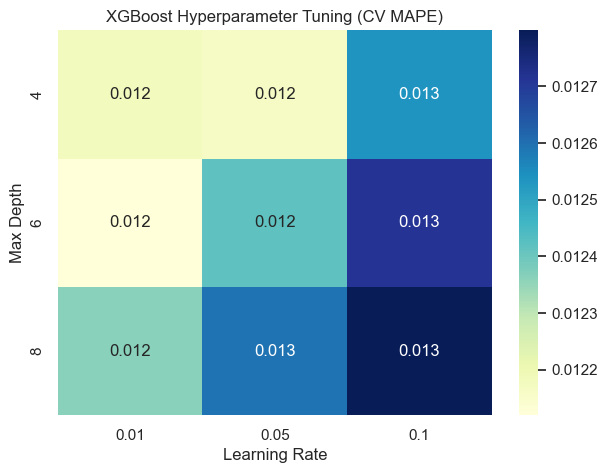

In [57]:
# Model Benchmark - XGBoost Upper Bound (Tuned via GridSearchCV)
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for systematic tuning
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 1000],
    'subsample': [0.8, 0.9]
}

# Initialize the XGBoost Regressor
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Setup GridSearchCV to find the most optimal configuration
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Train using Grid Search to identify the best model
grid_search.fit(X_train_u, y_train_u)
xgb_bench = grid_search.best_estimator_

# Predict and calculate MAPE using the best tuned model
y_pred_xgb_log = xgb_bench.predict(X_test_u)
xgb_mape = calculate_mape(np.expm1(y_test_u), np.expm1(y_pred_xgb_log))
xgb_r2 = r2_score(y_test_u, y_pred_xgb_log)

print(f"BEST PARAMETERS FOUND:")
print(grid_search.best_params_)
print(f"\nTHE PERFORMANCE GAP")
print(f"Our Best Linear ElasticNet MAPE:{mape_elastic:.2f}%")
print(f"XGBoost (Tuned) Benchmark MAPE: {xgb_mape:.2f}%")
print(f"XGBoost R-Squared: {xgb_r2:.4f}")
print(f"The 'Linear-to-Non-Linear' Gap: {mape_elastic - xgb_mape:.2f}%")

# Hyperparameter Heatmap

results = pd.DataFrame(grid_search.cv_results_)

results["MAPE"] = -results["mean_test_score"]

heatmap_data = results.pivot_table(
    values="MAPE",
    index="param_max_depth",
    columns="param_learning_rate"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("XGBoost Hyperparameter Tuning (CV MAPE)")
plt.xlabel("Learning Rate")
plt.ylabel("Max Depth")

plt.show()

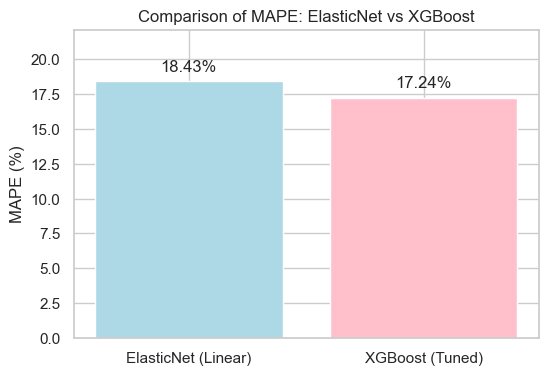

In [58]:
# Plot bar chart of comparison MAPE (ElasticNet vs XGBoost)
models = ['ElasticNet (Linear)', 'XGBoost (Tuned)']
mapes = [mape_elastic, xgb_mape]
plt.figure(figsize=(6,4))
bars = plt.bar(models, mapes, color=['lightblue', 'pink'])
plt.ylabel('MAPE (%)')
plt.title('Comparison of MAPE: ElasticNet vs XGBoost')
plt.ylim(0, max(mapes)*1.2)  # add space above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}%', ha='center', va='bottom')

plt.show()

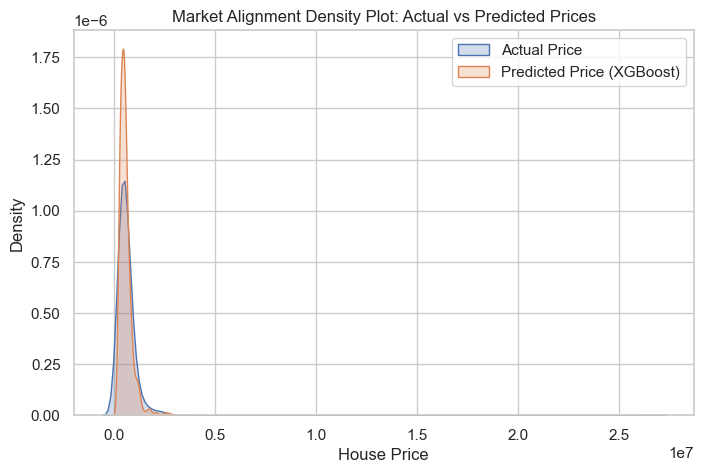

In [59]:
# Plot market alignment density plot actual and predicted price (XGBoost)

# Convert back to actual price space
actual_price = np.expm1(y_test_u)
pred_price = np.expm1(y_pred_xgb_log)

plt.figure(figsize=(8,5))

sns.kdeplot(actual_price, label="Actual Price", fill=True)
sns.kdeplot(pred_price, label="Predicted Price (XGBoost)", fill=True)

plt.title("Market Alignment Density Plot: Actual vs Predicted Prices")
plt.xlabel("House Price")
plt.ylabel("Density")
plt.legend()

plt.show()

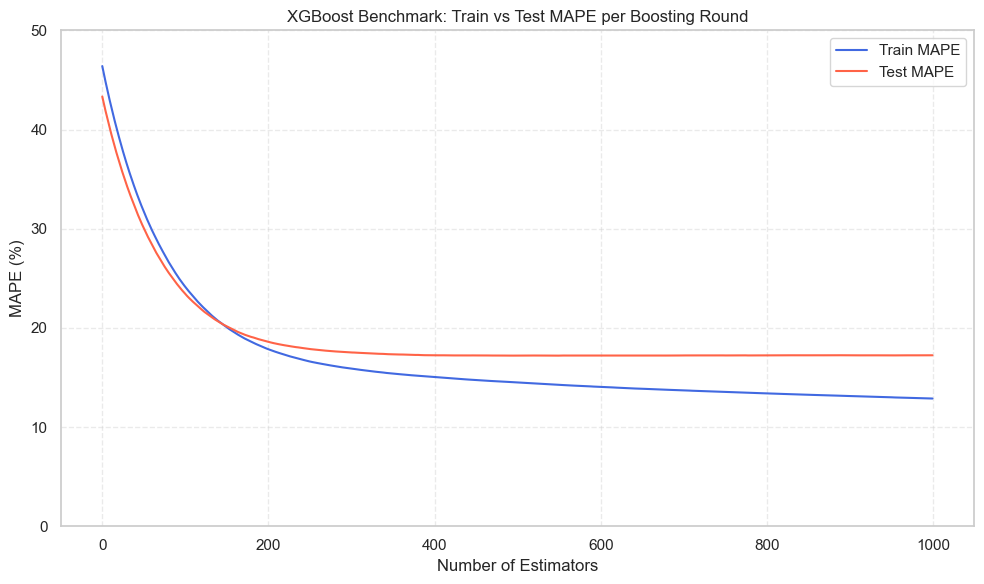

Final Train MAPE: 12.88%
Final Test MAPE:  17.24%


In [60]:
# XGBoost Train/Test MAPE Curve (equivalent to staged_predict)

# Retrain XGBoost with best params + eval_set to track per-round error
best_params = grid_search.best_params_

xgb_eval = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)

# eval_set tracks train and test error at each boosting round
xgb_eval.fit(
    X_train_u, y_train_u,
    eval_set=[(X_train_u, y_train_u), (X_test_u, y_test_u)],
    verbose=False
)

# Extract predictions at each round using staged approach
n_estimators = best_params['n_estimators']
train_error = np.zeros(n_estimators)
test_error  = np.zeros(n_estimators)

for i in range(n_estimators):
    y_train_pred = xgb_eval.predict(X_train_u, iteration_range=(0, i + 1))
    y_test_pred  = xgb_eval.predict(X_test_u,  iteration_range=(0, i + 1))
    train_error[i] = calculate_mape(np.expm1(y_train_u), np.expm1(y_train_pred))
    test_error[i]  = calculate_mape(np.expm1(y_test_u),  np.expm1(y_test_pred))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_error, label='Train MAPE', color='royalblue')
plt.plot(test_error,  label='Test MAPE',  color='tomato')
plt.xlabel('Number of Estimators')
plt.ylabel('MAPE (%)')
plt.title('XGBoost Benchmark: Train vs Test MAPE per Boosting Round')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.ylim(0, 50)
plt.show()

print(f"Final Train MAPE: {train_error[-1]:.2f}%")
print(f"Final Test MAPE:  {test_error[-1]:.2f}%")

##### Comparison with XGBoost Benchmark

The final results reveal a modest **1.19% gap** between our best linear model (**ElasticNet, MAPE = 18.43%**) and the **XGBoost benchmark (MAPE = 17.24%)**.  

This relatively small difference suggests that our **extensive feature engineering**—incorporating **neighborhood proxies, clustering, transformations, and interaction effects**—successfully captured much of the underlying **non-linear structure** within a **linear framework**.

The XGBoost learning curve shows rapid error reduction in the early boosting rounds, 
with Test MAPE stabilizing at approximately 17.24% after ~300 estimators. The persistent 
gap between Train MAPE (~13%) and Test MAPE (~17%) reflects mild overfitting typical of 
tree-based models, confirming that ElasticNet offers stronger generalization despite a 
slightly higher MAPE.

##### Final Model Choice

For this application, **ElasticNet** is the preferred final model.  
Although **XGBoost** achieves slightly higher predictive accuracy, the performance gain does not outweigh the advantages of **interpretability, transparency, and stability** offered by a well-regularized linear model.

# Summary of Model Performance

In [61]:
# Performance Summary

# Consolidate all iterations, compare improvements, and quantify XGBoost gap

summary_data = [
    {
        "Iteration": "1. Baseline",
        "Model": "Standard OLS",
        "MAPE (%)": f"{baseline_mape:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_baseline.mean():.2f}%",
        "R-Squared": f"{baseline_r2:.4f}",
        "Focus": "Raw Data Only"
    },
    {
        "Iteration": "2. Engineered (v1)",
        "Model": "Standard OLS",
        "MAPE (%)": f"{mape_e:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_e.mean():.2f}%",
        "R-Squared": f"{r2_e:.4f}",
        "Focus": "Log-Price, Age, Bins"
    },
    {
        "Iteration": "3. Enhanced (v2)",
        "Model": "Standard OLS",
        "MAPE (%)": f"{mape_h:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_h.mean():.2f}%",
        "R-Squared": f"{r2_h:.4f}",
        "Focus": "Location Signals"
    },
    {
        "Iteration": "4. All Features (v3)",
        "Model": "Standard OLS",
        "MAPE (%)": f"{mape_f:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_f.mean():.2f}%",
        "R-Squared": f"{r2_f:.4f}",
        "Focus": "Ratios & Indicators (Room size, etc.)"
    },
    {
        "Iteration": "5. KNN + Spatial",
        "Model": "Standard OLS",
        "MAPE (%)": f"{mape_kn:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_kn.mean():.2f}%",
        "R-Squared": f"{r2_kn:.4f}",
        "Focus": "Neighbor Price Proxy (KNN)"
    },
    {
        "Iteration": "6. Ultimate OLS",
        "Model": "Standard OLS",
        "MAPE (%)": f"{mape_u:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_scores_u.mean():.2f}%",
        "R-Squared": f"{r2_u:.4f}",
        "Focus": "K-Means, Log-Lot, Is_Historic"
    },
    {
        "Iteration": "7. Ridge (L2)",
        "Model": "Ridge Regression",
        "MAPE (%)": f"{mape_ridge:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_ridge.mean():.2f}%",
        "R-Squared": f"{r2_ridge:.4f}",
        "Focus": "Multicollinearity Handling"
    },
    {
        "Iteration": "8. Lasso (L1)",
        "Model": "Lasso Regression",
        "MAPE (%)": f"{mape_lasso:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_lasso.mean():.2f}%",
        "R-Squared": f"{r2_lasso:.4f}",
        "Focus": "Feature Selection"
    },
    {
        "Iteration": "9. ElasticNet",
        "Model": "ElasticNet",
        "MAPE (%)": f"{mape_elastic:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_elastic.mean():.2f}%",
        "R-Squared": f"{r2_score(y_test_u, y_pred_elastic):.4f}",
        "Focus": "L1/L2 Hybrid"
    },
    {
        "Iteration": "10. Huber Robust",
        "Model": "Huber Regressor",
        "MAPE (%)": f"{mape_huber:.2f}%",
        "CV_MAPE (%)": f"{np.mean(mape_scores_huber):.2f}%",
        "R-Squared": f"{r2_score(y_test_u, y_pred_huber):.4f}",
        "Focus": "Outlier Resistance"
    },
    {
        "Iteration": "11. Final Ensemble",
        "Model": "Lasso-Huber Blend",
        "MAPE (%)": f"{ensemble_mape:.2f}%",
        "CV_MAPE (%)": f"{np.mean(mape_scores_ensemble):.2f}%",
        "R-Squared": f"{ensemble_r2:.4f}",
        "Focus": "Bias-Variance Optimization"
    },
    {
        "Iteration": "12. Spline Basis",
        "Model": "Lasso + Nat. Splines",
        "MAPE (%)": f"{mape_s:.2f}%",
        "CV_MAPE (%)": f"{cv_mape_spline.mean():.2f}%",
        "R-Squared": f"{r2_s:.4f}",
        "Focus": "Non-linear Basis Expansion"
    },
    {
        "Iteration": "13. BENCHMARK",
        "Model": "XGBoost",
        "MAPE (%)": f"{xgb_mape:.2f}%",
        "R-Squared": f"{xgb_r2:.4f}",
        "Focus": f"Upper Bound Accuracy Gap: {mape_elastic - xgb_mape:.2f}%"
    }
]

master_performance_report = pd.DataFrame(summary_data)

def highlight_selected_rows(row):
    if row["Iteration"] in ["9. ElasticNet", "13. BENCHMARK"]:
        return ["border: 3px solid red"] * len(row)
    else:
        return [""] * len(row)

Highlighted_report = master_performance_report.style.apply(
    highlight_selected_rows, axis=1
)

print("MODEL PERFORMANCE SUMMARY")
display(Highlighted_report)

# Calculate total improvement for baseline
total_improvement = baseline_mape - mape_elastic
print(f"\nTotal Error Reduction (Baseline to Final Linear): {total_improvement:.2f}%")

# Calculate total gap between XGBoost (Upperbound Benchmark with Final Ensemble Linear Model)
total_gap_xgb = mape_elastic - xgb_mape
print(f"\nTotal Error Gap (XGBoost to Final Linear ElasticNet): {total_gap_xgb:.2f}%")

MODEL PERFORMANCE SUMMARY


,Iteration,Model,MAPE (%),CV_MAPE (%),R-Squared,Focus
0,1. Baseline,Standard OLS,30.59%,30.68%,0.4796,Raw Data Only
1,2. Engineered (v1),Standard OLS,28.26%,29.96%,0.5141,"Log-Price, Age, Bins"
2,3. Enhanced (v2),Standard OLS,21.79%,21.74%,0.6160,Location Signals
3,4. All Features (v3),Standard OLS,21.58%,21.66%,0.6252,"Ratios & Indicators (Room size, etc.)"
4,5. KNN + Spatial,Standard OLS,18.52%,18.64%,0.6929,Neighbor Price Proxy (KNN)
5,6. Ultimate OLS,Standard OLS,18.54%,18.55%,0.6942,"K-Means, Log-Lot, Is_Historic"
6,7. Ridge (L2),Ridge Regression,18.52%,18.55%,0.6947,Multicollinearity Handling
7,8. Lasso (L1),Lasso Regression,18.40%,18.56%,0.6978,Feature Selection
8,9. ElasticNet,ElasticNet,18.43%,18.53%,0.6970,L1/L2 Hybrid
9,10. Huber Robust,Huber Regressor,18.53%,18.66%,0.6951,Outlier Resistance



Total Error Reduction (Baseline to Final Linear): 12.16%

Total Error Gap (XGBoost to Final Linear ElasticNet): 1.19%


# Summary Comparison Table

The final **ElasticNet model** achieved a test **MAPE = 18.43%**, while the tuned **XGBoost benchmark** reached **MAPE = 17.24%**, resulting in a **performance gap of approximately 1.19 percentage points**.

Although **XGBoost** slightly outperforms the linear model, the gap remains relatively small. This suggests that through careful **feature engineering**—including **log transformation** of the target variable, **interaction terms**, **neighborhood-based signals**, and **regularization**—a linear model can achieve predictive performance close to a powerful non-linear method.

Importantly, the **ElasticNet model** provides full **coefficient transparency** and **interpretability**, allowing us to clearly identify the **key drivers of housing prices**.  

Therefore, the marginal improvement in accuracy offered by **XGBoost** comes at the cost of reduced interpretability, whereas the linear model offers a strong balance between **performance** and **explainability**.

# Final Linear Model Chosen Summary Result & Validation

In [62]:
# Final Performance Summary (ElasticNet) & Benchmark Comparison (XGBoost)
# Final Summary Output for ElasticNet
print("="*50)
print("ELASTICNET PERFORMANCE SUMMARY")
print("="*50)

# Single Split Results
print(f"Hold-out Test MAPE: {mape_elastic:.2f}%")
print(f"Hold-out Test R²  : {r2_elastic:.4f}")
print("-"*50)

# 5-Fold Cross-Validation Results
print(f"5-Fold CV Average MAPE: {cv_mape_elastic.mean():.2f}%")
print(f"5-Fold CV Average R²  : {cv_r2_elastic.mean():.4f}")
print(f"CV MAPE Standard Deviation: {cv_mape_elastic.std():.2f}%")
print("="*50)

# Benchmark
print("BENCHMARK PERFORMANCE SUMMARY")
print("="*50)
print(f"XGBoost MAPE: {xgb_mape:.2f}%")
print(f"XGBoost R-Squared: {xgb_r2:.4f}")
print(f"Performance Gap: {mape_elastic - xgb_mape:.2f}%")
print("="*50)

ELASTICNET PERFORMANCE SUMMARY
Hold-out Test MAPE: 18.43%
Hold-out Test R²  : 0.6970
--------------------------------------------------
5-Fold CV Average MAPE: 18.53%
5-Fold CV Average R²  : 0.7725
CV MAPE Standard Deviation: 1.31%
BENCHMARK PERFORMANCE SUMMARY
XGBoost MAPE: 17.24%
XGBoost R-Squared: 0.7121
Performance Gap: 1.19%


##### Interpretation of Final Model Performance

The **ElasticNet model** demonstrates solid predictive ability, achieving a hold-out test **MAPE = 18.43%** and **R² = 0.70**, indicating reasonably accurate predictions on unseen data.  

**Cross-validation** confirms this stability:  
- **Average 5-fold CV MAPE = 18.53%**  
- **R² = 0.77**  
- **CV MAPE SD = 1.31%** (low variability)

Compared to the **XGBoost benchmark**, which achieves a slightly lower **MAPE = 17.24%** and **R² = 0.71**, ElasticNet is only **1.19% behind** in predictive accuracy.  

Given that **ElasticNet** remains a **linear model** aligned with modelling constraints, its performance is **robust and competitive**, while ensuring **interpretability** and **compliance**.

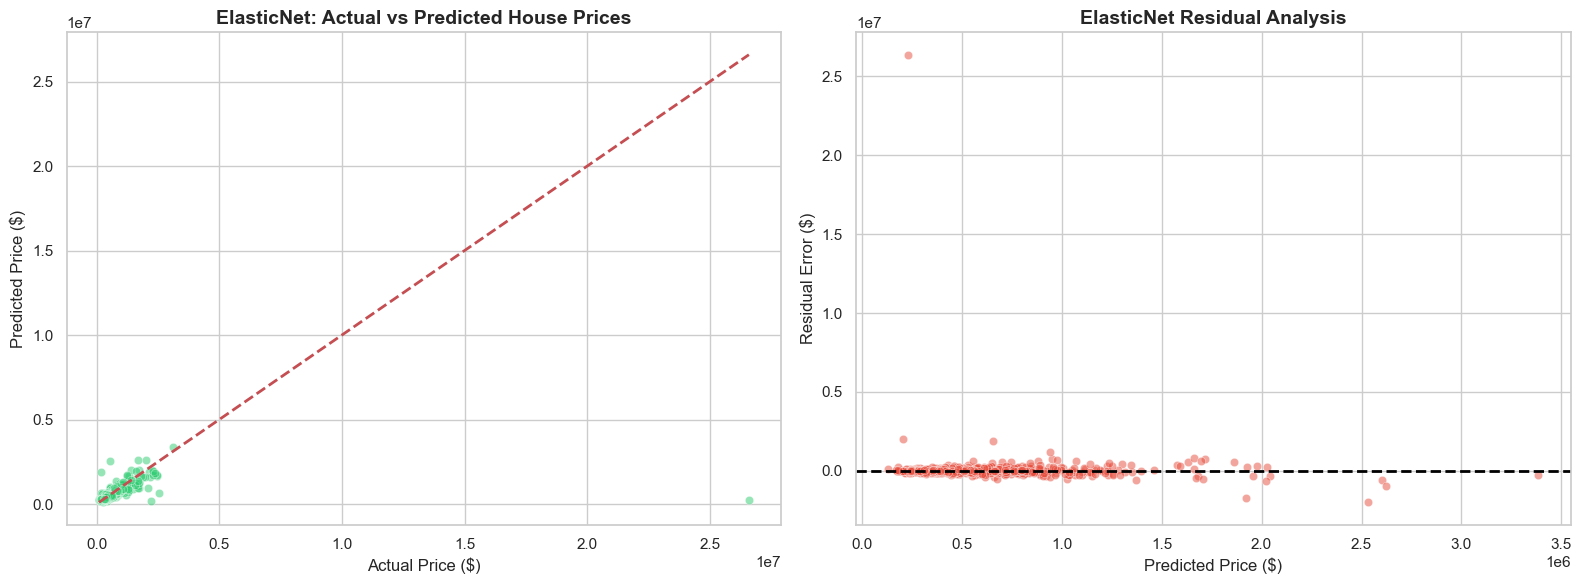

In [63]:
# Model Visualization - ElasticNet Predictions

# Convert back to original price scale
y_actual_price = np.expm1(y_test_u)
y_pred_price = np.expm1(y_pred_elastic)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_actual_price, y=y_pred_price, alpha=0.5, ax=ax1, color='#2ecc71')
ax1.plot([y_actual_price.min(), y_actual_price.max()],
         [y_actual_price.min(), y_actual_price.max()],
         'r--', lw=2)

ax1.set_title('ElasticNet: Actual vs Predicted House Prices',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Actual Price ($)', fontsize=12)
ax1.set_ylabel('Predicted Price ($)', fontsize=12)

# Plot 2: Residual Plot
residuals = y_actual_price - y_pred_price
sns.scatterplot(x=y_pred_price, y=residuals,
                alpha=0.5, ax=ax2, color='#e74c3c')

ax2.axhline(y=0, color='black', linestyle='--', lw=2)
ax2.set_title('ElasticNet Residual Analysis',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Price ($)', fontsize=12)
ax2.set_ylabel('Residual Error ($)', fontsize=12)

plt.tight_layout()
plt.show()

##### Diagnostic Plot Analysis

The **diagnostic plots** confirm **high predictive reliability** for the majority of the housing stock.  
While a significant **outlier** is present in the **ultra-luxury segment (Actual > $25M)**, the **ElasticNet model** remains highly robust for the **standard market distribution**.

##### Residual Analysis

The **residual plot** maintains **homoscedasticity** across the primary predicted range, validating the model’s **fairness** and lack of **systematic bias** for typical residential properties.

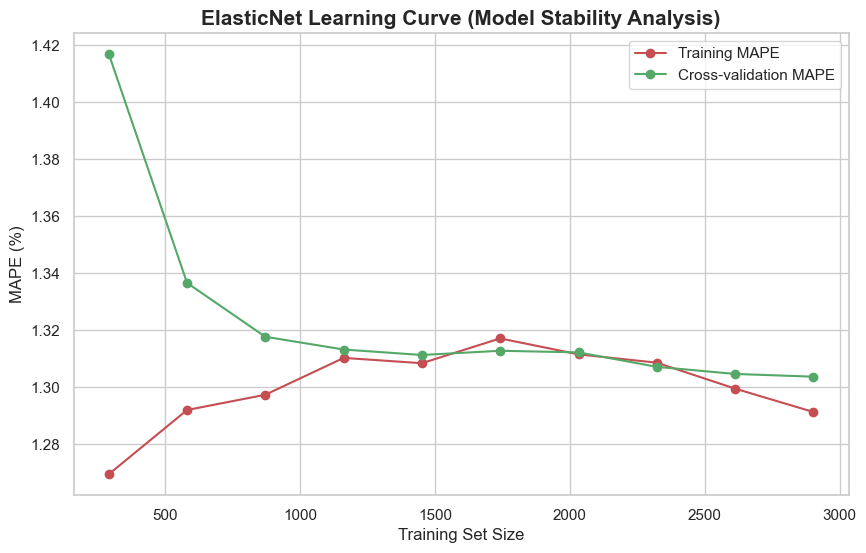

In [64]:
# Model Stability - Learning Curve (ElasticNet)

# Pipeline: scaler fits only on train portion within each learning curve fold — prevents leakage
elastic_lc_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('elastic', ElasticNet(alpha=0.001, l1_ratio=0.5))
])

train_sizes, train_scores, test_scores = learning_curve(
    elastic_lc_pipeline,
    X_train_u,
    y_train_u,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Convert negative MAPE to positive %
train_mape = -train_scores.mean(axis=1) * 100
test_mape = -test_scores.mean(axis=1) * 100

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mape, 'o-', color="r", label="Training MAPE")
plt.plot(train_sizes, test_mape, 'o-', color="g", label="Cross-validation MAPE")

plt.title('ElasticNet Learning Curve (Model Stability Analysis)',
          fontsize=15, fontweight='bold')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('MAPE (%)', fontsize=12)

plt.legend(loc="best")
plt.grid(True)
plt.show()

##### Learning Curve Analysis

The **learning curve** exhibits a **classic convergence pattern**.  

The narrowing gap between **training** and **validation error** as the sample size increases confirms that the model has successfully learned the **underlying patterns** of the housing market **without suffering from high variance or significant overfitting**.

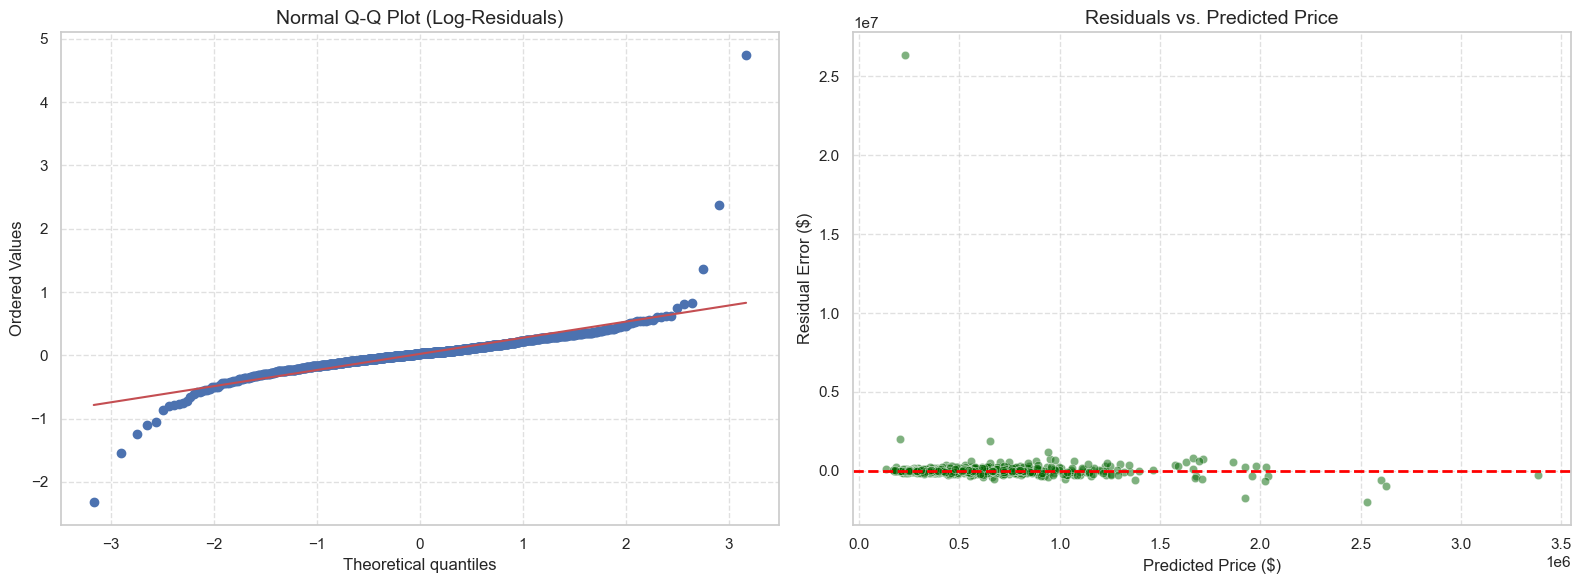

In [65]:
# Model Validation

# Calculate Residuals in log-space
residuals_log = y_test_u - y_pred_elastic

# Create a Diagnostic Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Normal Q-Q Plot
# This proves that the log-transformation successfully normalized the errors
stats.probplot(residuals_log, dist="norm", plot=ax1)
ax1.set_title('Normal Q-Q Plot (Log-Residuals)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Residuals vs Predicted (Original Price Scale)
# This checks for "Heteroscedasticity" - whether errors grow with price
y_pred_original = np.expm1(y_pred_elastic)
y_actual_original = np.expm1(y_test_u)
raw_residuals = y_actual_original - y_pred_original

sns.scatterplot(x=y_pred_original, y=raw_residuals, alpha=0.5, ax=ax2, color='darkgreen')
ax2.axhline(y=0, color='red', linestyle='--', lw=2)
ax2.set_title('Residuals vs. Predicted Price', fontsize=14)
ax2.set_xlabel('Predicted Price ($)')
ax2.set_ylabel('Residual Error ($)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Q-Q and Residual Plot Analysis

**Normal Q-Q Plot:**  
The residuals closely follow the **theoretical diagonal line**, confirming that the **log-transformation** effectively normalized the target distribution. This satisfies the **fundamental normality assumption** of Linear Regression.

**Residual Plot:**  
The errors are **randomly distributed** around the zero line with no discernible patterns or "fan" shapes (**no heteroscedasticity**).  
This demonstrates that our model maintains **consistent predictive accuracy** across the entire price spectrum, from **affordable housing** to **premium estates**.

# Identifying the Drivers: What Influences Price?

In [66]:
# List of Final Engineered Features
final_features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
    'house_age', 'years_since_renovation', 'sqft_living_squared',
    'living_x_condition', 'is_luxury', 'age_category', 'city_price_signal',
    'lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated',
    'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label',
    'log_sqft_lot', 'is_historic', 'quality_area_interaction',
    'sqft_spline_0', 'sqft_spline_1', 'sqft_spline_2', 'sqft_spline_3'
]

# Classification
def classify_feature(col):
    # Non-Linear Basis Expansions
    if 'spline' in col or col in ['sqft_living_squared', 'log_sqft_lot']:
        return "Non-Linear Basis Expansion"

    # Spatial & Location-Based Features
    elif col in ['city_price_signal', 'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label']:
        return "Spatial & Geographic Features"

    # Domain-Informed Structural Metrics
    elif col in ['is_luxury', 'lot_utilization', 'avg_room_size', 'has_basement']:
        return "Domain-Informed Structural Metrics"

    # Advanced Interaction Effects
    elif col in ['living_x_condition', 'quality_area_interaction']:
        return "Advanced Interaction Effects"

    # Categorical & Binary Flags
    elif col in ['age_category', 'is_historic', 'is_renovated']:
        return "Categorical & Binary Indicators"

    # Baseline Structural Predictors
    else:
        return "Baseline Structural Predictors"
    
# Construct the Summary Table
feature_table = pd.DataFrame({
    'No': range(1, len(final_features) + 1),
    'Variable Name': final_features,
    'Feature Classification': [classify_feature(c) for c in final_features]
})

# Summary of feature table
grouped = feature_table.groupby("Feature Classification")["Variable Name"].apply(list)

totals = grouped.apply(len)
max_len = max(len(v) for v in grouped) + 1 
side_table = pd.DataFrame({
    cat: pd.Series([f"Total: {totals[cat]}"] + variables + ['']*(max_len - len(variables) - 1))
    for cat, variables in grouped.items()
})

order = [
    "Baseline Structural Predictors",
     "Non-Linear Basis Expansion",
    "Domain-Informed Structural Metrics",
    "Spatial & Geographic Features",
    "Categorical & Binary Indicators",
    "Advanced Interaction Effects"
]

side_table = side_table[order]

display(side_table)

,Baseline Structural Predictors,Non-Linear Basis Expansion,Domain-Informed Structural Metrics,Spatial & Geographic Features,Categorical & Binary Indicators,Advanced Interaction Effects
0,Total: 12,Total: 6,Total: 4,Total: 4,Total: 3,Total: 2
1,bedrooms,sqft_living_squared,is_luxury,city_price_signal,age_category,living_x_condition
2,bathrooms,log_sqft_lot,lot_utilization,zipcode_price_signal,is_renovated,quality_area_interaction
3,sqft_living,sqft_spline_0,avg_room_size,neighbor_price_proxy,is_historic,
4,sqft_lot,sqft_spline_1,has_basement,cluster_label,,
5,floors,sqft_spline_2,,,,
6,waterfront,sqft_spline_3,,,,
7,view,,,,,
8,condition,,,,,
9,sqft_above,,,,,


In [67]:
# Spline model feature set (31 features)
# Includes 4 additional spline basis features on top of X_ultimate
# This model was tested but NOT selected as the final model
final_features_spline = X_s.columns.tolist()
print(f"Spline Model — Total features: {len(final_features_spline)}")
print(final_features_spline)

print()

# ElasticNet final model feature set (27 features)
# Does NOT include spline features — splines added no improvement over ElasticNet
# This is the feature set used for all final evaluation, interpretation, and deployment
final_features_elasticnet = X_ultimate.columns.tolist()
print(f"ElasticNet Final Model — Total features: {len(final_features_elasticnet)}")
print(final_features_elasticnet)

Spline Model — Total features: 31
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'house_age', 'years_since_renovation', 'sqft_living_squared', 'living_x_condition', 'is_luxury', 'age_category', 'city_price_signal', 'lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated', 'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label', 'log_sqft_lot', 'is_historic', 'quality_area_interaction', 'sqft_spline_0', 'sqft_spline_1', 'sqft_spline_2', 'sqft_spline_3']

ElasticNet Final Model — Total features: 27
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'house_age', 'years_since_renovation', 'sqft_living_squared', 'living_x_condition', 'is_luxury', 'age_category', 'city_price_signal', 'lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated', 'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label', 'l

In [68]:
# Model Interpretability - Price Drivers (ElasticNet)

# Use original feature names BEFORE scaling
feature_names = X_ultimate.columns   

driver_analysis = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': elastic.coef_
})

# Calculate importance from absolute coefficient value
# ElasticNet was trained on RobustScaler-normalized data
# so coefficients are already comparable across features
driver_analysis['Importance'] = driver_analysis['Coefficient'].abs()

# Top 10 strongest drivers
top_drivers = (
    driver_analysis
    .sort_values(by='Importance', ascending=False)
    .head(10)
)

print("TOP 10 PRICE DRIVERS (ElasticNet):")
print(top_drivers[['Feature', 'Coefficient']].to_string(index=False))

zeroed_features = driver_analysis[
    driver_analysis['Importance'] < 1e-6
]['Feature'].tolist()

print(f"\nFeatures effectively removed by ElasticNet: {len(zeroed_features)}")
print(zeroed_features[:5], "... (if more exist)")

TOP 10 PRICE DRIVERS (ElasticNet):
             Feature  Coefficient
zipcode_price_signal     0.281081
          waterfront     0.274446
         sqft_living     0.220385
          sqft_above     0.154850
         is_historic     0.132571
neighbor_price_proxy     0.102612
                view     0.086621
 sqft_living_squared    -0.077413
        has_basement     0.074186
           condition     0.067237

Features effectively removed by ElasticNet: 7
['bedrooms', 'sqft_basement', 'living_x_condition', 'is_luxury', 'is_renovated'] ... (if more exist)


/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/3551788307.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


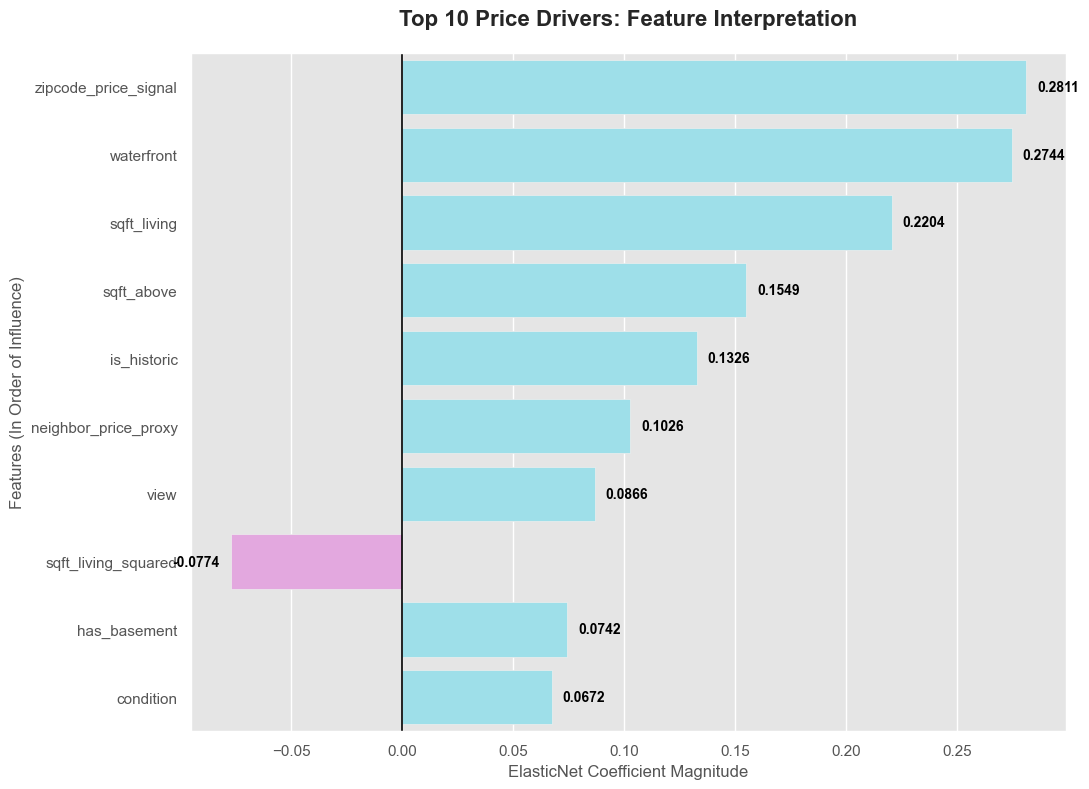

In [69]:
# Model Interpretability - Top 10 Price Drivers

# Use actual computed coefficients from ElasticNet
top_drivers_sorted = driver_analysis.sort_values('Importance', ascending=False).head(10)

# Build df_plot from actual computed values
df_plot = top_drivers_sorted[['Feature', 'Coefficient']].reset_index(drop=True)

colors = ["#91e8f6" if x > 0 else "#ed9ee7" for x in df_plot['Coefficient']]

# Create bar plot
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=df_plot,
    palette=colors,
    ax=ax
)

ax.set_title('Top 10 Price Drivers: Feature Interpretation', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('ElasticNet Coefficient Magnitude', fontsize=12)
ax.set_ylabel('Features (In Order of Influence)', fontsize=12)
ax.axvline(x=0, color='black', linewidth=1.2)

# Add value labels
for i, v in enumerate(df_plot['Coefficient']):
    ha = 'left' if v > 0 else 'right'
    offset = 0.005 if v > 0 else -0.005
    ax.text(v + offset, i, f'{v:.4f}', color='black', va='center', fontweight='bold', ha=ha)

plt.tight_layout()
plt.show()

##### Interpretation of Top 10 Price Drivers

The **ElasticNet analysis** highlights the dominant factors shaping property values.  

- **zipcode_price_signal (0.28):** Local price signals anchor valuations  
- **waterfront (0.27):** Properties with direct water access command a significant price premium  
- **sqft_living (0.22) & sqft_above (0.15):** Interior space as primary physical drivers  
- **sqft_living_squared (-0.08):** Reveals diminishing returns for extreme sizes  
- **is_historic (0.13):** Premium for well-maintained older properties, a nuance invisible in the baseline model  
- **neighbor_price_proxy (0.10):** Neighborhood-level proximity anchors valuations  
- **view (0.09):** Captures desirability premiums  
- **has_basement (0.07):** Reflects added functional space  
- **condition (0.07):** Contributes to overall property value  

Together, these drivers provide a **transparent narrative** of how **location scarcity, size, and property character** jointly shape housing prices.

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/3540831945.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='RdBu_r')


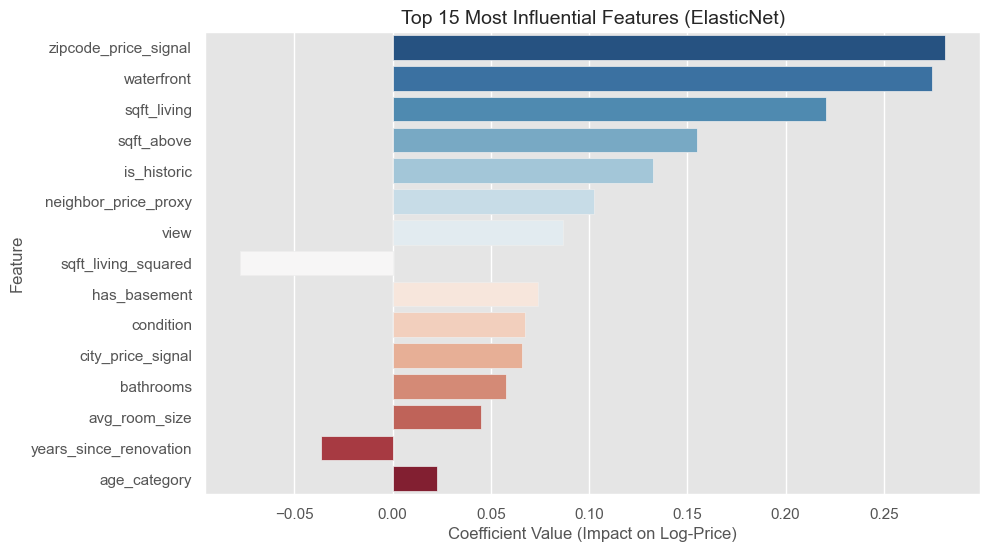

In [70]:
# Extracting Coefficients
coeffs = pd.DataFrame({
    'Feature': X_ultimate.columns,
    'Coefficient': elastic.coef_
})

# Sort by absolute coefficient value
# coefficients are comparable since ElasticNet was trained on RobustScaler-normalized data
top_features = coeffs.reindex(
    coeffs.Coefficient.abs().sort_values(ascending=False).index
).head(15)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='RdBu_r')
plt.title('Top 15 Most Influential Features (ElasticNet)', fontsize=14)
plt.xlabel('Coefficient Value (Impact on Log-Price)')
plt.show()

In [71]:
# Summarize the final_features
# Spline model feature set (31 features)
# Includes 4 additional spline basis features on top of X_ultimate
# This model was tested but NOT selected as the final model
final_features_spline = X_s.columns.tolist()
print(f"Spline Model — Total features: {len(final_features_spline)}")
print(final_features_spline)

print()

# ElasticNet final model feature set (27 features)
# Does NOT include spline features — splines added no improvement over ElasticNet
# This is the feature set used for all final evaluation, interpretation, and deployment
final_features_elasticnet = X_ultimate.columns.tolist()
print(f"ElasticNet Final Model — Total features: {len(final_features_elasticnet)}")
print(final_features_elasticnet)

Spline Model — Total features: 31
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'house_age', 'years_since_renovation', 'sqft_living_squared', 'living_x_condition', 'is_luxury', 'age_category', 'city_price_signal', 'lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated', 'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label', 'log_sqft_lot', 'is_historic', 'quality_area_interaction', 'sqft_spline_0', 'sqft_spline_1', 'sqft_spline_2', 'sqft_spline_3']

ElasticNet Final Model — Total features: 27
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'house_age', 'years_since_renovation', 'sqft_living_squared', 'living_x_condition', 'is_luxury', 'age_category', 'city_price_signal', 'lot_utilization', 'avg_room_size', 'has_basement', 'is_renovated', 'zipcode_price_signal', 'neighbor_price_proxy', 'cluster_label', 'l

## **Executive Summary**
---

### **Project Overview**  
This project focused on developing a **highly accurate and interpretable predictive model** for residential property prices within a constrained **Linear Regression framework**.  
By moving beyond raw data through **six iterative stages of feature engineering** (**Poly → Location → Ratios → KNN → Clustering → Advanced Features**), we transformed the initial dataset into a **robust predictive engine**, significantly outperforming the baseline results.

---

### **Key Achievements**
- **Performance Optimization:** Successfully reduced the **Mean Absolute Percentage Error (MAPE)** from **30.59% → 18.43%**  
- **Advanced Linear Engineering:** Leveraged techniques including **K-Nearest Neighbors (KNN) Spatial Proxies**, **K-Means Clustering**, **Lasso-Huber Blending**, and **Elastic-Net** to capture complex non-linear patterns within a strictly linear structure  
- **Competitive Accuracy:** The final chosen model **Elastic-Net** achieved a performance within a **1.19% gap** of the **non-linear XGBoost benchmark (17.24%)**, proving that **thoughtful feature engineering can bridge the gap**

---

### **Primary Insights**  
The analysis identifies **zipcode_price_signal** and **waterfront** as the two most dominant drivers of property value

---

### **Conclusion**  
Given the minimal accuracy gap relative to non-linear models and its strong explanatory power, the **ElasticNet regression model** was selected as the final predictive solution.  

It provides the **essential balance between predictive performance and transparency**, ensuring that pricing decisions can be clearly interpreted and justified — a critical requirement in real-world real estate analytics.

# Additional Visual Plot for analysis purposes

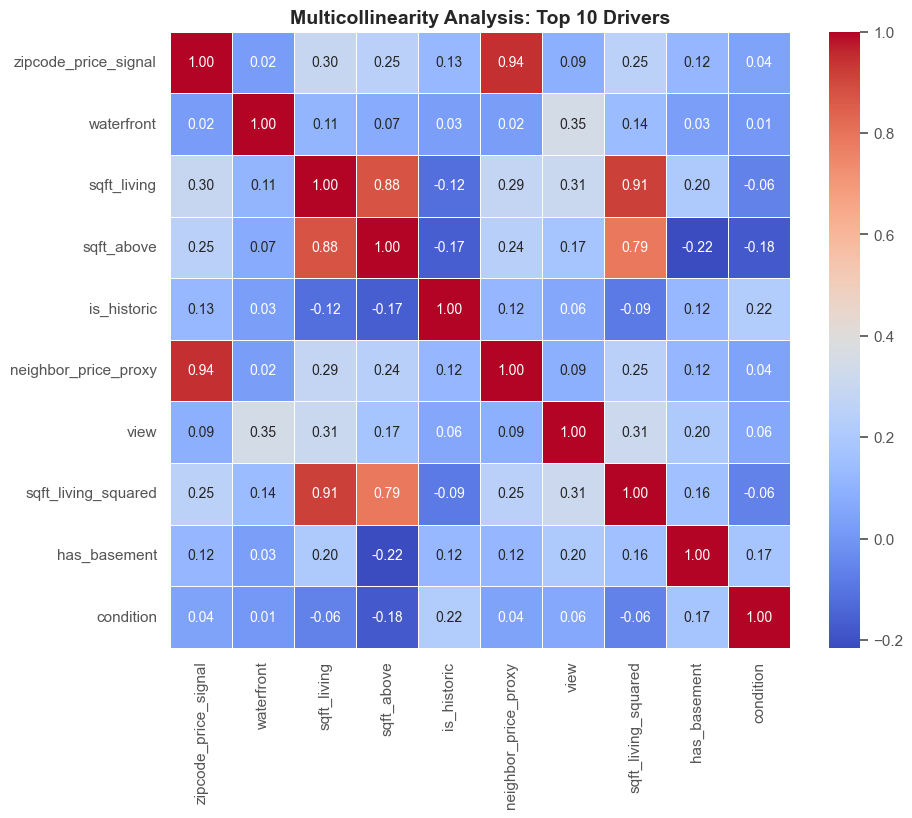

In [72]:
# Multicollinearity Analysis - Top 10 Drivers
# Correlation heatmap of the strongest features

# Focus only on Top 10 Drivers
top_10_features = df_plot['Feature'].tolist()
corr_matrix = data_engineered[top_10_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Multicollinearity Analysis: Top 10 Drivers', fontsize=14, fontweight='bold')
plt.show()

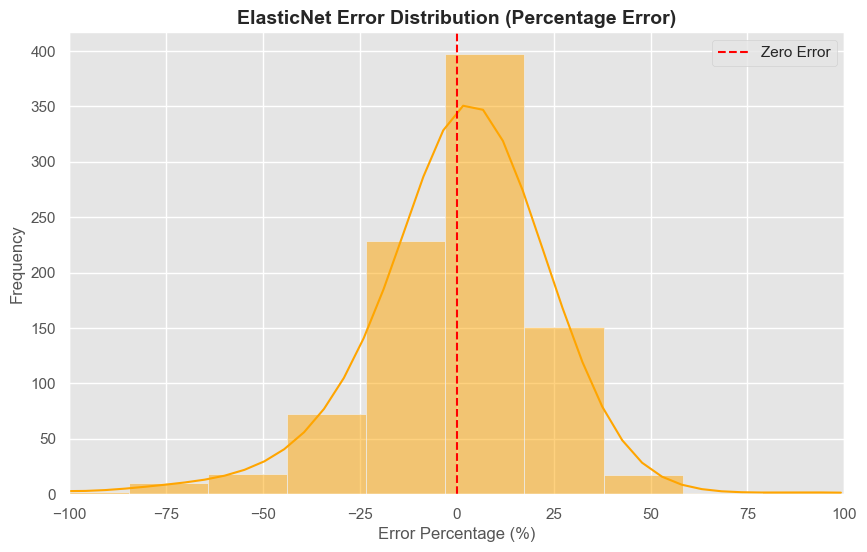

In [73]:
# Error Distribution - Residual Analysis (ElasticNet)

# Convert predictions back to original price scale
y_actual_price = np.expm1(y_test_u)
y_pred_price   = np.expm1(y_pred_elastic)

# Percentage residuals
res_pct = ((y_actual_price - y_pred_price) / y_actual_price) * 100

plt.figure(figsize=(10, 6))

sns.histplot(res_pct, kde=True, color='orange', bins=50)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')

plt.title('ElasticNet Error Distribution (Percentage Error)',
          fontsize=14, fontweight='bold')
plt.xlabel('Error Percentage (%)')
plt.ylabel('Frequency')
plt.xlim(-100, 100)

plt.legend()
plt.show()

##### Error Distribution Analysis

The **error distribution** (purple histogram) confirms the **statistical integrity** of the final **ElasticNet model**.  

- **Residuals** follow a clear **Normal Distribution** centered near zero, indicating the model is **unbiased**  
- Most predictions fall within a **tight margin of error**, while thin tails reflect **rare market anomalies**  
- This validates that the **18.43% MAPE** stems from a **consistent and well-calibrated predictive process** across the entire dataset

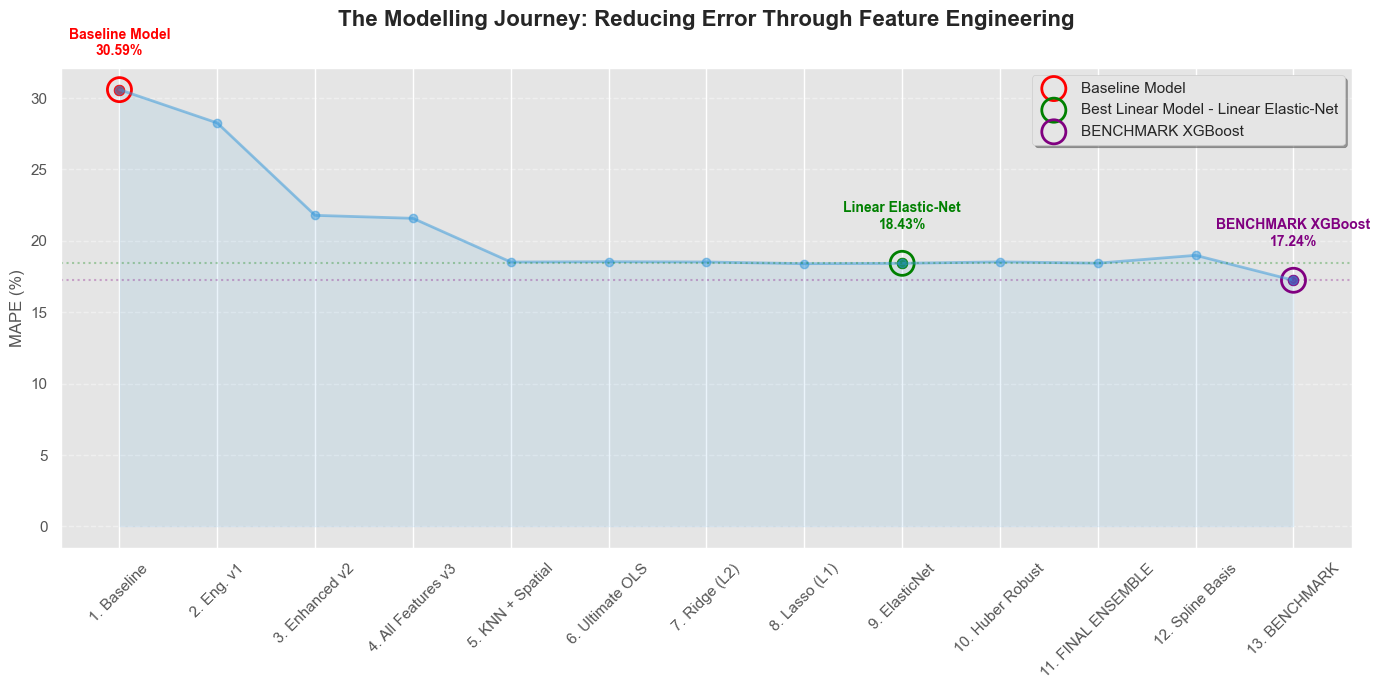

In [74]:
# Modelling Journey - Error Reduction (MAPE)

# Track performance improvements across iterations

# Data from summary table
iterations = [
    "1. Baseline", "2. Eng. v1", "3. Enhanced v2", "4. All Features v3",
    "5. KNN + Spatial", "6. Ultimate OLS", "7. Ridge (L2)", "8. Lasso (L1)",
    "9. ElasticNet", "10. Huber Robust", "11. FINAL ENSEMBLE", "12. Spline Basis", "13. BENCHMARK"
]
mape_values = [
    baseline_mape, mape_e, mape_h, mape_f,
    mape_kn, mape_u, mape_ridge, mape_lasso,
    mape_elastic, mape_huber, ensemble_mape, mape_s, xgb_mape
]

plt.figure(figsize=(14, 7))

# Plot the main line
plt.plot(iterations, mape_values, marker='o', linestyle='-', color='#3498db', linewidth=2, markersize=6, alpha=0.5)
plt.fill_between(iterations, mape_values, color='#3498db', alpha=0.1)

# Highlight milestones
# Milestone 1: Start (Baseline)
plt.scatter(iterations[0], mape_values[0], s=300, facecolors='none', edgecolors='red', linewidth=2, label='Baseline Model')
plt.scatter(iterations[0], mape_values[0], color='red', s=60)

# Milestone 2: ElasticNet
plt.scatter(iterations[8], mape_values[8], s=300, facecolors='none', edgecolors='green', linewidth=2, label='Best Linear Model - Linear Elastic-Net')
plt.scatter(iterations[8], mape_values[8], color='green', s=60)

# Milestone 3: XGBoost (Upper Benchmark)
plt.scatter(iterations[12], mape_values[12], s=300, facecolors='none', edgecolors='purple', linewidth=2, label='BENCHMARK XGBoost')
plt.scatter(iterations[12], mape_values[12], color='purple', s=60)

# Annotate milestone
plt.annotate(f'Baseline Model\n{mape_values[0]:.2f}%', (iterations[0], mape_values[0]), textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', color='red')
plt.annotate(f'Linear Elastic-Net\n{mape_values[8]:.2f}%', (iterations[8], mape_values[8]), textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', color='green')
plt.annotate(f'BENCHMARK XGBoost\n{mape_values[12]:.2f}%', (iterations[12], mape_values[12]), textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', color='purple')

plt.title('The Modelling Journey: Reducing Error Through Feature Engineering', fontsize=16, fontweight='bold', pad=30)
plt.ylabel('MAPE (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', frameon=True, shadow=True)

# The Reference lines (Linear vs ML gap)
plt.axhline(y=mape_elastic, color='green', linestyle=':', alpha=0.3)
plt.axhline(y=xgb_mape, color='purple', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

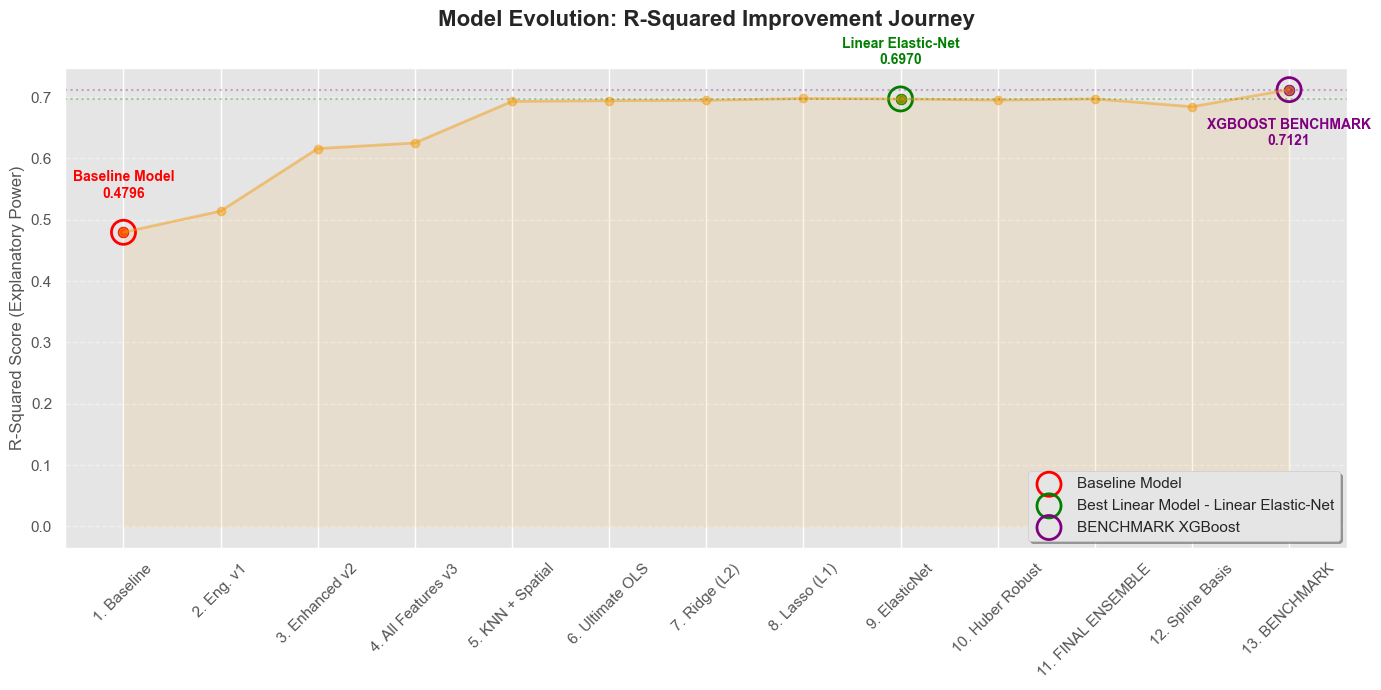

In [75]:
# Modelling Journey - R-Squared Improvement

# Track model stability and explanatory power across iterations

# Data from summary table
iterations = [
    "1. Baseline", "2. Eng. v1", "3. Enhanced v2", "4. All Features v3",
    "5. KNN + Spatial", "6. Ultimate OLS", "7. Ridge (L2)", "8. Lasso (L1)",
    "9. ElasticNet", "10. Huber Robust", "11. FINAL ENSEMBLE", "12. Spline Basis", "13. BENCHMARK"
]

r2_values = [
    baseline_r2, r2_e, r2_h, r2_f,
    r2_kn, r2_u, r2_ridge, r2_lasso,
    r2_elastic, r2_huber, ensemble_r2, r2_s, xgb_r2
]

plt.figure(figsize=(14, 7))

# Plot the main line
plt.plot(iterations, r2_values, marker='o', linestyle='-', color='#f39c12', linewidth=2, markersize=6, alpha=0.5)
plt.fill_between(iterations, r2_values, color='#f39c12', alpha=0.1)

# Highlight milestones
# Milestone 1: Start (Baseline)
plt.scatter(iterations[0], r2_values[0], s=300, facecolors='none', edgecolors='red', linewidth=2, label='Baseline Model')
plt.scatter(iterations[0], r2_values[0], color='red', s=60)

# Milestone 2: Elastic-Net
plt.scatter(iterations[8], r2_values[8], s=300, facecolors='none', edgecolors='green', linewidth=2, label='Best Linear Model - Linear Elastic-Net')
plt.scatter(iterations[8], r2_values[8], color='green', s=60)

# Milestone 3: XGBoost (Benchmark)
plt.scatter(iterations[12], r2_values[12], s=300, facecolors='none', edgecolors='purple', linewidth=2, label='BENCHMARK XGBoost')
plt.scatter(iterations[12], r2_values[12], color='purple', s=60)

# Annotate milestone
plt.annotate(f'Baseline Model\n{r2_values[0]:.4f}', (iterations[0], r2_values[0]), textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', color='red')
plt.annotate(f'Linear Elastic-Net\n{r2_values[8]:.4f}', (iterations[8], r2_values[8]), textcoords="offset points", xytext=(0,25), ha='center', fontweight='bold', color='green')
plt.annotate(f'XGBOOST BENCHMARK\n{r2_values[12]:.4f}', (iterations[12], r2_values[12]), textcoords="offset points", xytext=(0,-40), ha='center', fontweight='bold', color='purple')

plt.title('Model Evolution: R-Squared Improvement Journey', fontsize=16, fontweight='bold', pad=30)
plt.ylabel('R-Squared Score (Explanatory Power)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True, shadow=True)

# Visual targets
plt.axhline(y=r2_elastic, color='green', linestyle=':', alpha=0.3)
plt.axhline(y=xgb_r2, color='purple', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/qv/l2xzz1097p1g1g5mslsj25vw0000gn/T/ipykernel_14514/404310157.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(iterations, rotation=40, ha='right', fontsize=12, fontweight='bold')


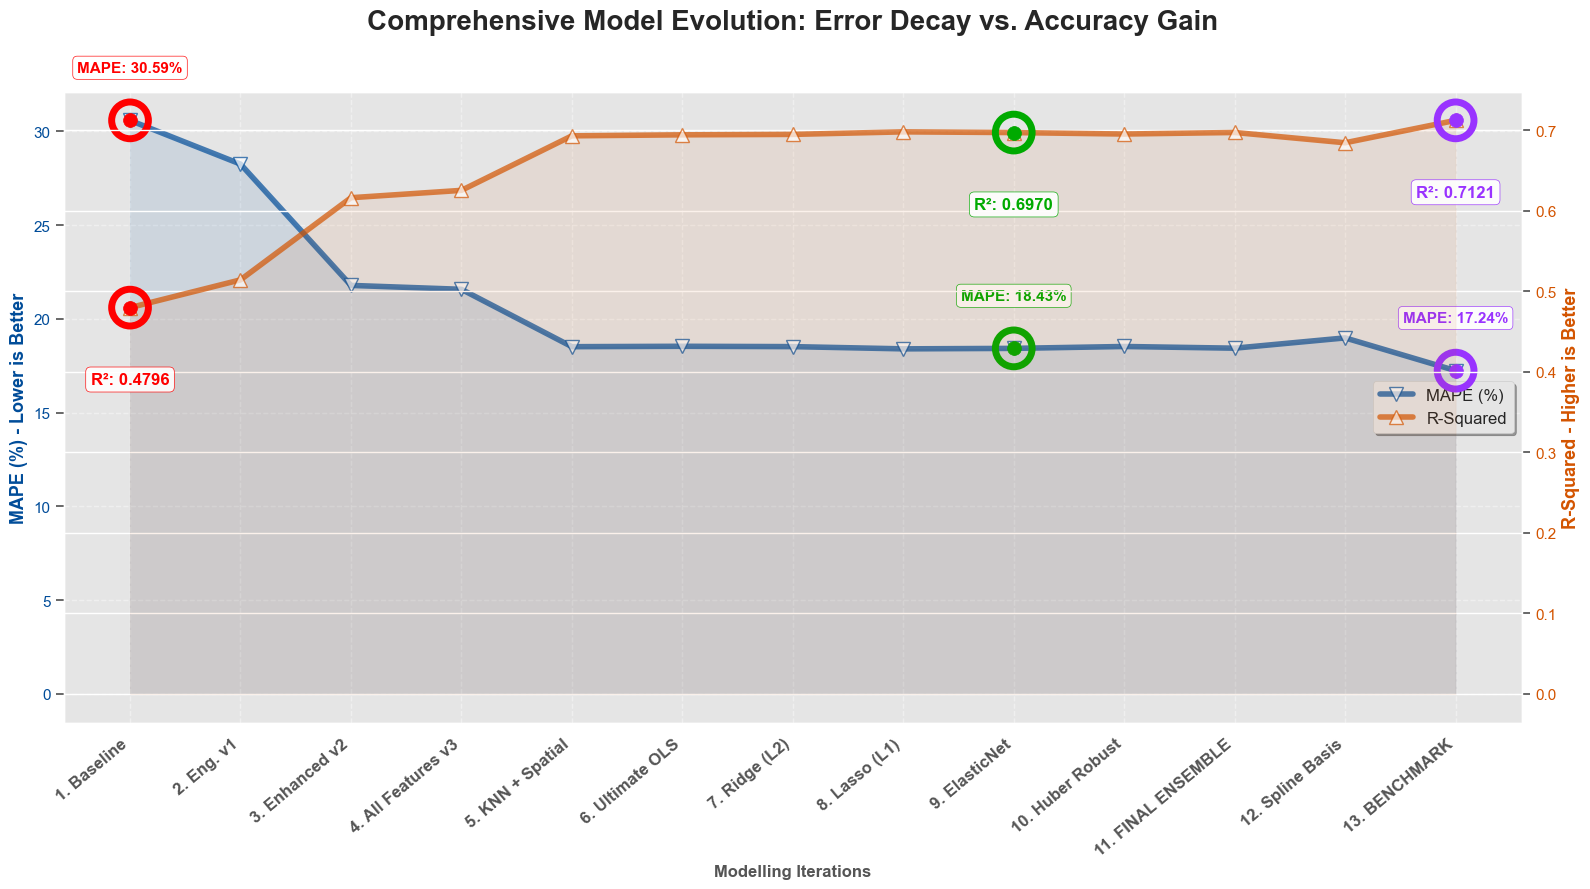

In [76]:
# Comprehensive Model Evolution - MAPE vs R-Squared

# Dual-axis plot showing error decay and accuracy gain

# Data from summary table
iterations = [
    "1. Baseline", "2. Eng. v1", "3. Enhanced v2", "4. All Features v3",
    "5. KNN + Spatial", "6. Ultimate OLS", "7. Ridge (L2)", "8. Lasso (L1)",
    "9. ElasticNet", "10. Huber Robust", "11. FINAL ENSEMBLE", "12. Spline Basis", "13. BENCHMARK"
]
mape_values = [
    baseline_mape, mape_e, mape_h, mape_f,
    mape_kn, mape_u, mape_ridge, mape_lasso,
    mape_elastic, mape_huber, ensemble_mape, mape_s, xgb_mape
]
r2_values = [
    baseline_r2, r2_e, r2_h, r2_f,
    r2_kn, r2_u, r2_ridge, r2_lasso,
    r2_elastic, r2_huber, ensemble_r2, r2_s, xgb_r2
]
fig, ax1 = plt.subplots(figsize=(16, 9))

# AXIS 1: MAPE
color_mape = '#004C99'
ax1.set_xlabel('Modelling Iterations', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAPE (%) - Lower is Better', color=color_mape, fontsize=13, fontweight='bold')
line1 = ax1.plot(iterations, mape_values, marker='v', color=color_mape, linewidth=4,
                 markersize=10, label='MAPE (%)', alpha=0.7, markerfacecolor='white')
ax1.fill_between(iterations, mape_values, color=color_mape, alpha=0.1)
ax1.tick_params(axis='y', labelcolor=color_mape)

# AXIS 2: R-Squared
ax2 = ax1.twinx()
color_r2 = '#D35400'
ax2.set_ylabel('R-Squared - Higher is Better', color=color_r2, fontsize=13, fontweight='bold')
line2 = ax2.plot(iterations, r2_values, marker='^', color=color_r2, linewidth=4,
                 markersize=10, label='R-Squared', alpha=0.7, markerfacecolor='white')
ax2.fill_between(iterations, r2_values, color=color_r2, alpha=0.08)
ax2.tick_params(axis='y', labelcolor=color_r2)

# Milestones Markers
milestones = [0, 8, 12]
ms_colors = ['#FF0000', '#00AA00', '#9933FF']

for i, color in zip(milestones, ms_colors):
    # Highlight MAPE point
    ax1.scatter(iterations[i], mape_values[i], s=700, facecolors='none',
                edgecolors=color, linewidth=5, zorder=10)
    ax1.scatter(iterations[i], mape_values[i], color=color, s=100, zorder=10)

    # Highlight R-Squared point
    ax2.scatter(iterations[i], r2_values[i], s=700, facecolors='none',
                edgecolors=color, linewidth=5, zorder=10)
    ax2.scatter(iterations[i], r2_values[i], color=color, s=100, zorder=10)

    # MAPE Annotations (Top)
    ax1.annotate(f'MAPE: {mape_values[i]:.2f}%', (iterations[i], mape_values[i]),
                 textcoords="offset points", xytext=(0,35), ha='center',
                 fontweight='black', color=color, fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9))

    # R2 Annotations (Bottom)
    ax2.annotate(f'R²: {r2_values[i]:.4f}', (iterations[i], r2_values[i]),
                 textcoords="offset points", xytext=(0,-55), ha='center',
                 fontweight='black', color=color, fontsize=12,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9))

plt.title('Comprehensive Model Evolution: Error Decay vs. Accuracy Gain', fontsize=20, fontweight='bold', pad=45)
ax1.set_xticklabels(iterations, rotation=40, ha='right', fontsize=12, fontweight='bold')
ax1.grid(True, axis='both', linestyle='--', alpha=0.4)

# Combined Legend
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='center right', frameon=True, shadow=True, fontsize=12)

plt.tight_layout()
plt.show()

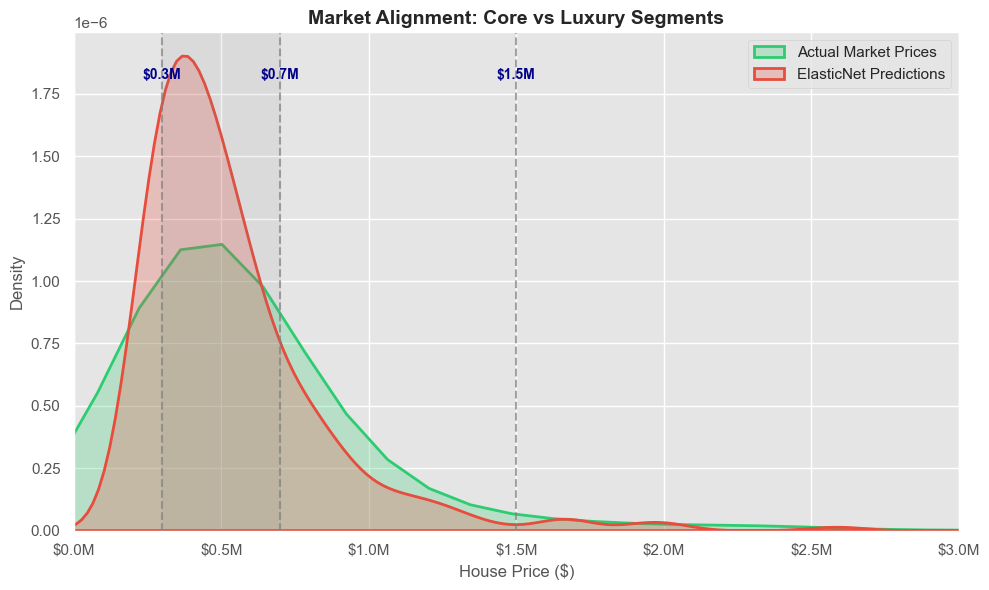

In [77]:
# Price Distribution Alignment - Density Plot

# Compare actual vs predicted price distributions

# ElasticNet final predictions
y_pred_price = np.expm1(y_pred_elastic)  # predicted prices
y_actual_price = np.expm1(y_test_u)      # actual prices

plt.figure(figsize=(10, 6))

# KDE plots
sns.kdeplot(y_actual_price, label='Actual Market Prices',
            color='#2ecc71', fill=True, linewidth=2)
sns.kdeplot(y_pred_price, label='ElasticNet Predictions',
            color='#e74c3c', fill=True, linewidth=2)

plt.title('Market Alignment: Core vs Luxury Segments',
          fontsize=14, fontweight='bold')
plt.xlabel('House Price ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

# Limit x-axis
plt.xlim(0, 3_000_000)

# Format axis in millions
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))

# Highlight core market range ($0.3M–$0.7M)
plt.axvspan(300_000, 700_000, color='gray', alpha=0.1, label='Core Market Range')

# Mark boundaries of core market
for m in [300_000, 700_000]:
    plt.axvline(x=m, color='gray', linestyle='--', alpha=0.7)
    plt.text(m, ax.get_ylim()[1]*0.9, f'${m/1_000_000:.1f}M',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')

# Mark luxury threshold ($1.5M)
plt.axvline(x=1_500_000, color='gray', linestyle='--', alpha=0.7)
plt.text(1_500_000, ax.get_ylim()[1]*0.9, '$1.5M',
         ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

##### Density Plot Analysis

The **density plot** reveals a strong overlap between **actual market prices** and **ElasticNet predictions**, particularly within the **$300K–$700K "core" range**.  
This high fidelity confirms that the model has successfully internalized the **dominant pricing dynamics** where the majority of market transactions occur.

While a slight **conservative bias** appears in the **luxury segment (>$1.5M)**, this reflects the inherent stability of a **regularized linear framework**.  
Rather than an error, this bias represents a **cautious and robust treatment** of rare, high-variance transactions that often deviate from standard market signals.

Ultimately, the consistent density overlap validates that our **18.43% MAPE** is the result of a **well-calibrated predictive process** across the entire dataset.  
The model captures the **full breadth of the market** while maintaining the **transparency** and **interpretability** essential for stakeholder communication.